# Line-Noise Removal Benchmark on the Runabout Dataset (ds003620)

**Goal.** Compare three line-noise removal strategies on mobile EEG recorded
at 50 Hz mains frequency, using standardised QA metrics.  The Runabout dataset
contains **three mobility conditions** (Lab, Oval, Campus), each introducing
distinct non-stationarity in line-noise amplitude and frequency drift.  We
evaluate how each method performs under these different conditions.

## Methods under test

| Tag | Method | Implementation |
|-----|--------|----------------|
| **M0** | No cleaning (baseline) | Raw data after shared preprocessing |
| **M1** | Standard ZapLine | `ZapLine(n_remove="auto", n_harmonics=3)` — automatic component selection |
| **M2** | Adaptive ZapLine+ | `ZapLine(adaptive=True, adaptive_params=...)` — segment-wise adaptive |

## Conditions (from ds003620)

| Condition | Environment | Expected Non-stationarity |
|-----------|-------------|---------------------------|
| **Lab** | Seated, controlled lab | Low — stable impedance, minimal motion artifacts |
| **Oval** | Walking, open field | Medium — rhythmic gait, moderate EMI variation |
| **Campus** | Walking, campus path | High — variable terrain, environmental EMI sources |

## QA metrics (computed per subject, per method, per condition)

| Metric | What it measures |
|--------|-----------------|
| **R(f₀)** — Noise-surround ratio | Peak/floor ratio ±1 Hz around f₀ (→ 1 is ideal) |
| **Peak attenuation (dB)** | Mean power reduction at f₀ ± 0.05 Hz |
| **Below-noise ΔPower (%)** | % change in integrated power in [f₀−11, f₀−1] Hz (→ 0 is ideal) |
| **Overclean proportion** | Fraction of bins near f₀ that dip below the spectral floor |
| **Underclean proportion** | Fraction of bins near f₀ still above sideband level |

All PSD computations use the **geometric-mean PSD** (mean of log₁₀-PSDs across
channels via `scipy.signal.welch`), matching the paper-5 reference.

## Design

- **N_SUBJECTS** controls how many subjects to run (default 2 for quick demo)
- Condition blocks are identified from `trigger_corrected` events (Lab/Oval/Campus)
- Metrics are computed per condition segment, enabling condition × method analysis

## 1 — Configuration

In [21]:
# ── Run-mode toggle ──────────────────────────────────────────────────────────
SMOKE = False                     # True → 1 subject; False → all subjects
N_SUBJECTS = 2                    # Number of subjects to run (when SMOKE=False)

# ── Dataset ──────────────────────────────────────────────────────────────────
DATASET_ID = "ds003620"
DATASET_VERSION = "1.1.1"
LINE_FREQ = 50.0                   # European mains frequency (Hz)
LINE_HARMONICS = 3                 # Number of harmonics to consider
TASK = "oddball"                   # BIDS task label (all conditions in one file)

# ── Preprocessing constants (shared, before line-noise removal) ──────────────
RESAMPLE_FREQ = 250                # Hz (matches paper)
HIGHPASS_FREQ = 0.5                # Hz (FIR, before line-noise step)
ORIG_SFREQ = 500.0                 # Original recording sfreq (for event onsets)

# ── Condition structure ──────────────────────────────────────────────────────
# The Runabout dataset has 3 mobility conditions recorded in one session:
#   LAB    — seated in a controlled laboratory
#   OVAL   — walking outdoors on an open oval/field
#   CAMPUS — walking outdoors on a campus path
# Each condition introduces different non-stationarity in line noise due to
# subject movement, muscle artifacts, and environmental EMI variation.
CONDITIONS = ["lab", "oval", "campus"]
CONDITION_LABELS = {"lab": "Lab (seated)", "oval": "Oval (walking)", "campus": "Campus (walking)"}
CONDITION_COLORS = {"lab": "#0072B2", "oval": "#E69F00", "campus": "#D55E00"}

# ── PSD parameters ───────────────────────────────────────────────────────────
PSD_FMAX = 125.0                   # Max frequency for PSD plots

# ── Paths ────────────────────────────────────────────────────────────────────
import pathlib
DATA_ROOT = pathlib.Path(r"d:\mne-denoise\condescending-liskov\data\runabout")
DERIV_ROOT = DATA_ROOT / "derivatives" / "mne-denoise"

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42

# ── Subject list (populated after download) ──────────────────────────────────
ALL_SUBJECTS = None   # filled in Section 3

print(f"Mode: {'SMOKE (1 subject)' if SMOKE else f'FULL ({N_SUBJECTS} subjects)'}")
print(f"Line frequency: {LINE_FREQ} Hz, harmonics: {LINE_HARMONICS}")
print(f"Conditions: {CONDITIONS}")
print(f"Data root: {DATA_ROOT}")

Mode: FULL (2 subjects)
Line frequency: 50.0 Hz, harmonics: 3
Conditions: ['lab', 'oval', 'campus']
Data root: d:\mne-denoise\condescending-liskov\data\runabout


## 2 — Imports

In [22]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy import stats

# ── QA metrics (from package) ────────────────────────────────────────────────
from mne_denoise.qa import (
    below_noise_distortion,
    compute_all_qa_metrics,
    geometric_mean_psd,
    noise_surr_ratio,
    overclean_proportion,
    peak_attenuation_db,
    underclean_proportion,
)

# ── Denoisers ────────────────────────────────────────────────────────────────
from mne_denoise.zapline import ZapLine

# ── Visualization (method-specific diagnostics) ─────────────────────────────
from mne_denoise.viz import (
    plot_zapline_summary,
    plot_adaptive_summary,
)

# ── Visualization (benchmark figures) ────────────────────────────────────────
from mne_denoise.viz import (
    plot_qc_psd,
    plot_psd_gallery,
    plot_subject_psd_overlay,
    plot_metric_bars,
    plot_tradeoff_scatter,
    plot_tradeoff_and_r,
    plot_r_comparison,
    plot_harmonic_attenuation,
    plot_paired_metrics,
    set_pub_style,
    DEFAULT_METHOD_COLORS,
    DEFAULT_METHOD_LABELS,
    DEFAULT_METHOD_ORDER,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")

%matplotlib inline
set_pub_style()

print(f"MNE version: {mne.__version__}")
print(f"NumPy version: {np.__version__}")

MNE version: 1.11.0
NumPy version: 2.4.2


## 3 — Data Discovery

Discover available subjects from the local copy of the Runabout dataset.


In [23]:
# Data is already downloaded — discover subjects directly
ds_path = DATA_ROOT
sub_dirs = sorted([d.name for d in ds_path.iterdir()
                   if d.is_dir() and d.name.startswith("sub-")])

if SMOKE:
    ALL_SUBJECTS = sub_dirs[:1]
else:
    ALL_SUBJECTS = sub_dirs[:N_SUBJECTS]

print(f"Found {len(sub_dirs)} subjects; using {len(ALL_SUBJECTS)}: {ALL_SUBJECTS}")


Found 44 subjects; using 2: ['sub-01', 'sub-02']


## 4 — Shared Preprocessing

All four methods receive the **same** preprocessed continuous data:

1. Load raw BrainVision file
2. Resample to 250 Hz
3. Pick EEG channels + reintroduce FCz (online reference)
4. Re-reference to linked mastoids (TP9 + TP10), then drop mastoids
5. High-pass filter at 0.5 Hz (FIR)

Line-noise removal is **not** applied here — that is the variable under test.


In [24]:
def load_and_preprocess(sub, ds_path):
    """Load raw data and apply shared preprocessing steps.

    Parameters
    ----------
    sub : str
        Subject ID, e.g. "sub-001".
    ds_path : Path
        Path to the downloaded dataset root.

    Returns
    -------
    raw : mne.io.Raw
        Preprocessed continuous data (before line-noise removal).
    """
    # Find the .vhdr file
    eeg_dir = ds_path / sub / "eeg"
    vhdr_files = sorted(eeg_dir.glob("*.vhdr"))
    if not vhdr_files:
        raise FileNotFoundError(f"No .vhdr file found for {sub} in {eeg_dir}")
    raw = mne.io.read_raw_brainvision(str(vhdr_files[0]), preload=True,
                                       verbose=False)

    # Fix encoding issues in channel names (if any)
    mapping = {}
    for ch in raw.ch_names:
        cleaned = ch.encode("latin-1", errors="replace").decode("utf-8", errors="replace")
        if cleaned != ch:
            mapping[ch] = cleaned
    if mapping:
        raw.rename_channels(mapping)

    # Step 1: Resample
    raw.resample(RESAMPLE_FREQ, verbose=False)

    # Step 2: Pick EEG + add back online reference (FCz)
    raw.pick_types(eeg=True, verbose=False)
    if "FCz" not in raw.ch_names:
        raw.add_reference_channels("FCz")
    raw.set_montage("standard_1020", on_missing="warn")

    # Step 3: Re-reference to linked mastoids
    mastoids = [ch for ch in ["TP9", "TP10"] if ch in raw.ch_names]
    if len(mastoids) == 2:
        raw.set_eeg_reference(mastoids, verbose=False)
        raw.drop_channels(mastoids)
    else:
        raw.set_eeg_reference("average", verbose=False)

    # Step 4: High-pass filter
    raw.filter(l_freq=HIGHPASS_FREQ, h_freq=None, method="fir",
               fir_design="firwin", verbose=False)

    return raw


# Quick test
_test_raw = load_and_preprocess(ALL_SUBJECTS[0], DATA_ROOT)
print(f"Test load: {_test_raw.info['nchan']} channels, "
      f"{_test_raw.n_times/_test_raw.info['sfreq']:.1f} s "
      f"at {_test_raw.info['sfreq']} Hz")
del _test_raw


Test load: 31 channels, 3134.1 s at 250.0 Hz


## 4b — Condition Block Parsing

Each subject's recording contains 3 mobility conditions (Lab, Oval, Campus)
interleaved with rest breaks.  We parse the **trigger-corrected** events from
derivatives to identify the time boundaries of each condition block.

The events encode condition as a suffix: `*_lab`, `*_oval`, `*_campus`.
We identify contiguous blocks of each condition and record their start/end
times so that after denoising we can compute metrics per condition segment.

In [25]:
def parse_condition_blocks(sub, ds_path=DATA_ROOT, sfreq_orig=ORIG_SFREQ,
                          sfreq_new=RESAMPLE_FREQ, gap_thresh=5.0, pad=1.0):
    """Identify contiguous condition blocks from trigger-corrected events.

    Parameters
    ----------
    sub : str
        Subject ID (e.g. "sub-01").
    ds_path : Path
        Dataset root path.
    sfreq_orig : float
        Original recording sample rate (event onsets are in original samples).
    sfreq_new : float
        Resampled rate (block boundaries are returned in seconds at this rate).
    gap_thresh : float
        Maximum inter-trial gap (s) within one block.  Gaps larger than this
        start a new block.
    pad : float
        Padding (s) added before first / after last event in each block.

    Returns
    -------
    blocks : dict
        ``{condition: [(tmin, tmax), ...]}`` with times in seconds relative
        to the raw recording start (at sfreq_new).
    """
    trig_path = (
        ds_path / "derivatives" / "trigger_corrected" / sub / "eeg"
        / f"{sub}_task-{TASK}_desc-trig_events.tsv"
    )
    if not trig_path.exists():
        print(f"  {sub}: trigger_corrected events not found — skipping conditions")
        return {}

    df = pd.read_csv(trig_path, sep="\t")
    df = df[df["trial_type"] != "empty"].copy()

    # Parse environment from trial_type suffix: *_lab, *_oval, *_campus
    def _get_env(tt):
        for env in CONDITIONS:
            if tt.endswith(f"_{env}"):
                return env
        return None

    df["env"] = df["trial_type"].apply(_get_env)
    df = df.dropna(subset=["env"])
    df["onset_s"] = df["onset"] / sfreq_orig  # convert samples → seconds

    blocks = {c: [] for c in CONDITIONS}

    for env in CONDITIONS:
        env_df = df[df["env"] == env].sort_values("onset_s")
        if env_df.empty:
            continue

        # Identify contiguous blocks (gaps < gap_thresh)
        onsets = env_df["onset_s"].values
        block_start = onsets[0]
        prev = onsets[0]

        for t in onsets[1:]:
            if t - prev > gap_thresh:
                # Close current block
                blocks[env].append((
                    max(0, block_start - pad),
                    prev + pad,
                ))
                block_start = t
            prev = t

        # Close final block
        blocks[env].append((
            max(0, block_start - pad),
            prev + pad,
        ))

    # Summary
    for env in CONDITIONS:
        n_blocks = len(blocks[env])
        if n_blocks:
            total_s = sum(e - s for s, e in blocks[env])
            print(f"  {sub} {env}: {n_blocks} block(s), {total_s:.0f} s total")
        else:
            print(f"  {sub} {env}: no events found")

    return blocks


def crop_to_condition(raw, tmin, tmax):
    """Crop a Raw object to [tmin, tmax], clamping to valid range."""
    t_start = max(tmin, raw.times[0])
    t_end = min(tmax, raw.times[-1])
    if t_end <= t_start:
        return None
    return raw.copy().crop(tmin=t_start, tmax=t_end)


# Test on first subject
_test_blocks = parse_condition_blocks(ALL_SUBJECTS[0])
print(f"\nTest blocks for {ALL_SUBJECTS[0]}: "
      f"{sum(len(v) for v in _test_blocks.values())} total block(s)")

  sub-01 lab: 5 block(s), 858 s total
  sub-01 oval: 5 block(s), 863 s total
  sub-01 campus: 5 block(s), 858 s total

Test blocks for sub-01: 15 total block(s)


## 5 — Method Definitions

Each method is a callable `(raw) → (raw_cleaned, model_info, estimator)` where
`model_info` is a dict of metadata and `estimator` is the fitted model for
diagnostic plots.

| Method | Key parameters |
|--------|---------------|
| M0 | No-op |
| M1 | `ZapLine(n_remove="auto", n_harmonics=3)` |
| M2 | `ZapLine(adaptive=True, adaptive_params={...})` |

In [26]:
def method_m0(raw):
    """M0: No line-noise removal (baseline)."""
    return raw.copy(), {"method": "M0_baseline", "description": "No cleaning"}, None


def method_m1(raw):
    """M1: Standard ZapLine (automatic component selection).

    Matches paper5: n_remove="auto", n_harmonics=3.
    """
    zap = ZapLine(
        sfreq=raw.info["sfreq"],
        line_freq=LINE_FREQ,
        n_remove="auto",
        n_harmonics=LINE_HARMONICS,
    )
    raw_clean = zap.fit_transform(raw.copy())
    info = {
        "method": "M1_zapline_standard",
        "n_remove": "auto",
        "n_harmonics": LINE_HARMONICS,
        "n_removed_": getattr(zap, "n_removed_", None),
    }
    return raw_clean, info, zap


def method_m2(raw):
    """M2: Adaptive ZapLine+ (segment-wise adaptive).

    Matches paper5: adaptive=True with adaptive_params for segment-wise
    peak detection and component removal.
    """
    zap = ZapLine(
        sfreq=raw.info["sfreq"],
        line_freq=LINE_FREQ,
        adaptive=True,
        adaptive_params={
            "n_remove_params": {
                "sigma": 3.0,
                "min_remove": 1,
                "max_prop": 0.2,
            },
        },
        n_harmonics=LINE_HARMONICS,
    )
    raw_clean = zap.fit_transform(raw.copy())
    info = {
        "method": "M2_zapline_adaptive",
        "adaptive": True,
        "n_harmonics": LINE_HARMONICS,
        "n_removed_": getattr(zap, "n_removed_", None),
    }
    return raw_clean, info, zap


def method_m3(raw):
    """M3: Standard MNE notch filter.

    Uses mne.io.Raw.notch_filter at line_freq + harmonics with a 2 Hz notch
    width (±1 Hz from centre).  Only harmonics below Nyquist are included.
    This is the simplest possible approach and serves as a traditional
    baseline for comparison.
    """
    nyquist = raw.info["sfreq"] / 2.0
    freqs = [LINE_FREQ * h for h in range(1, LINE_HARMONICS + 1)
             if LINE_FREQ * h < nyquist]
    raw_clean = raw.copy()
    raw_clean.notch_filter(
        freqs=freqs,
        notch_widths=2.0,   # 2 Hz total width (±1 Hz)
        method="fir",
        verbose=False,
    )
    info = {
        "method": "M3_notch_filter",
        "freqs": freqs,
        "notch_widths": 2.0,
        "filter_method": "fir",
        "nyquist": nyquist,
    }
    return raw_clean, info, None


METHODS = {
    "M0": method_m0,
    "M1": method_m1,
    "M2": method_m2,
}
# Use package defaults minus M3 (notch) — kept only ZapLine variants
METHOD_LABELS = {k: v for k, v in DEFAULT_METHOD_LABELS.items() if k != "M3"}
METHOD_COLORS = {k: v for k, v in DEFAULT_METHOD_COLORS.items() if k != "M3"}
METHOD_ORDER = [m for m in DEFAULT_METHOD_ORDER if m != "M3"]

print(f"Defined {len(METHODS)} methods: {list(METHODS.keys())}")
for mtag, label in METHOD_LABELS.items():
    print(f"  {mtag}: {label}")

Defined 3 methods: ['M0', 'M1', 'M2']
  M0: Baseline (no cleaning)
  M1: ZapLine (auto)
  M2: ZapLine+ (adaptive)


## 6 — QA Metric Functions

All metrics use the **geometric-mean PSD** (mean of log₁₀-PSDs across channels),
matching the paper-5 methodology.  Default bandwidths are narrow
(`center_bw = 0.05 Hz ≈ 1 FFT bin`) for precise spectral peak targeting.

- **R(f₀)**: Noise-surround ratio — ideal ≈ 1 (peak gone)
- **Peak attenuation (dB)**: Mean power reduction at f₀ ± 0.05 Hz — higher = better
- **Below-noise ΔPower (%)**: % change in integrated power [f₀−11, f₀−1] Hz — near 0 = best
- **Overclean proportion**: Fraction of bins near f₀ below spectral floor — lower = better
- **Underclean proportion**: Fraction of bins near f₀ still above sideband — lower = better

In [27]:
# QA metric functions are now imported from mne_denoise.qa (Section 2).
# Available: geometric_mean_psd, noise_surr_ratio, peak_attenuation_db,
#            below_noise_distortion, overclean_proportion, underclean_proportion,
#            compute_all_qa_metrics
#
# All use the geometric-mean PSD (mean of log-PSDs via scipy.signal.welch).

print("✓ QA metric functions imported from mne_denoise.qa")


✓ QA metric functions imported from mne_denoise.qa


## 7 — Output Contract & Per-Subject Diagnostics

Each subject × method produces:

```
derivatives/mne-denoise/runabout/{sub}/line_noise/{method}/
    cleaned_raw.fif          # Cleaned continuous data
    metrics.tsv              # QA metrics (whole-recording)
    condition_metrics.tsv    # QA metrics per condition block
    qc_psd.png               # Before/after geometric-mean PSD
    diagnostics.png           # Method-specific diagnostic dashboard
    model.json                # Denoiser parameters + fit metadata
```

In [28]:
def _save_model_json(model_info, path):
    """Write model metadata dict to JSON (numpy-safe)."""
    import json

    def _default(o):
        if isinstance(o, np.integer):
            return int(o)
        if isinstance(o, np.floating):
            return float(o)
        if isinstance(o, np.ndarray):
            return o.tolist()
        raise TypeError(f"Cannot serialize {type(o)}")

    with open(path, "w") as f:
        json.dump(model_info, f, indent=2, default=_default)


# ── Method-specific diagnostic dispatcher ────────────────────────────────────

_DIAG_DISPATCH = {
    "M1": plot_zapline_summary,
    "M2": plot_adaptive_summary,
}


def save_outputs(sub, method_tag, raw_before, raw_after, metrics_dict,
                 model_info, estimator=None, condition_metrics=None,
                 deriv_root=DERIV_ROOT):
    """Save outputs + generate per-subject diagnostics for one method.

    Returns
    -------
    out_dir : Path
    """
    out_dir = deriv_root / sub / "line_noise" / method_tag
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1. Cleaned raw
    raw_after.save(out_dir / "cleaned_raw.fif", overwrite=True, verbose=False)

    # 2. Metrics TSV (whole-recording)
    flat = {k: v for k, v in metrics_dict.items()
            if not isinstance(v, (list, dict))}
    df = pd.DataFrame([flat])
    df.insert(0, "subject", sub)
    df.insert(1, "method", method_tag)
    df.to_csv(out_dir / "metrics.tsv", sep="\t", index=False)

    # 2b. Condition-level metrics TSV
    if condition_metrics:
        cond_rows = []
        for cond, cmetrics in condition_metrics.items():
            cflat = {k: v for k, v in cmetrics.items()
                     if not isinstance(v, (list, dict))}
            cflat["subject"] = sub
            cflat["method"] = method_tag
            cflat["condition"] = cond
            cond_rows.append(cflat)
        if cond_rows:
            df_cond = pd.DataFrame(cond_rows)
            cols = ["subject", "method", "condition"] + [
                c for c in df_cond.columns
                if c not in ("subject", "method", "condition")
            ]
            df_cond = df_cond[cols]
            df_cond.to_csv(out_dir / "condition_metrics.tsv",
                           sep="\t", index=False)

    # 3. QC PSD figure — compute geometric-mean PSDs from raw objects
    freqs_b, gm_b = geometric_mean_psd(raw_before)
    freqs_a, gm_a = geometric_mean_psd(raw_after)
    fig_psd = plot_qc_psd(
        freqs_b, gm_b, freqs_a, gm_a,
        method_tag=method_tag,
        subject=sub,
        metrics_dict=metrics_dict,
        fmax=PSD_FMAX,
        show=False,
    )
    fig_psd.savefig(out_dir / "qc_psd.png", dpi=300, bbox_inches="tight")
    plt.close(fig_psd)

    # 4. Method-specific diagnostics dashboard (skip for M0)
    diag_fn = _DIAG_DISPATCH.get(method_tag)
    if diag_fn is not None and estimator is not None:
        try:
            fig_diag = diag_fn(
                estimator,
                data_before=raw_before.get_data(),
                data_after=raw_after.get_data(),
                sfreq=raw_before.info["sfreq"],
                title=f"{sub} — {method_tag}",
                show=False,
            )
            fig_diag.savefig(out_dir / "diagnostics.png", dpi=300,
                             bbox_inches="tight")
            plt.close(fig_diag)
        except Exception as e:
            print(f"    [diag] {method_tag} diagnostic plot failed: {e}")

    # 5. Model metadata
    _save_model_json(model_info, out_dir / "model.json")

    return out_dir


print("✓ save_outputs() defined")

✓ save_outputs() defined


## 8 — Per-Subject Processing

`process_subject(sub)` runs all three methods on one subject, saves results to
disk, and generates diagnostic dashboards.  For each method, metrics are computed
on the **whole recording** and also on each **condition segment** (Lab/Oval/Campus).

In [29]:
def process_subject(sub, ds_path=None, deriv_root=DERIV_ROOT):
    """Run all line-noise methods on one subject, save to disk.

    Returns
    -------
    results : list of dict
        One dict per method × condition with subject, method, condition, and metrics.
        Also includes one row per method with condition="all" for the whole recording.
    """
    if ds_path is None:
        ds_path = DATA_ROOT

    print(f"\n{'='*60}")
    print(f"  Processing {sub}")
    print(f"{'='*60}")

    # Load and preprocess
    raw_base = load_and_preprocess(sub, ds_path)
    sfreq = raw_base.info["sfreq"]
    print(f"  Loaded: {raw_base.info['nchan']} ch, "
          f"{raw_base.n_times/sfreq:.1f} s at {sfreq} Hz")

    # Parse condition blocks
    cond_blocks = parse_condition_blocks(sub, ds_path)

    results = []
    cleaned_psds = {}  # {method_tag: (freqs, gm_psd)}

    # Compute baseline PSD
    freqs_base, gm_base = geometric_mean_psd(raw_base)

    for method_tag in METHOD_ORDER:
        print(f"  ── {method_tag}: {METHOD_LABELS[method_tag]} ... ", end="")
        try:
            raw_clean, model_info, estimator = METHODS[method_tag](raw_base)

            # Compute whole-recording QA metrics
            metrics = compute_all_qa_metrics(
                raw_base, raw_clean,
                line_freq=LINE_FREQ,
                n_harmonics=LINE_HARMONICS,
            )

            # ── Condition-level metrics ──────────────────────────────────
            condition_metrics = {}
            for cond in CONDITIONS:
                if cond not in cond_blocks or not cond_blocks[cond]:
                    continue

                # Concatenate all blocks for this condition
                pieces_before = []
                pieces_after = []
                for tmin, tmax in cond_blocks[cond]:
                    seg_b = crop_to_condition(raw_base, tmin, tmax)
                    seg_a = crop_to_condition(raw_clean, tmin, tmax)
                    if seg_b is not None and seg_a is not None:
                        pieces_before.append(seg_b)
                        pieces_after.append(seg_a)

                if not pieces_before:
                    continue

                # Concatenate blocks of same condition
                if len(pieces_before) == 1:
                    raw_cond_b = pieces_before[0]
                    raw_cond_a = pieces_after[0]
                else:
                    raw_cond_b = mne.concatenate_raws(pieces_before)
                    raw_cond_a = mne.concatenate_raws(pieces_after)

                cmetrics = compute_all_qa_metrics(
                    raw_cond_b, raw_cond_a,
                    line_freq=LINE_FREQ,
                    n_harmonics=LINE_HARMONICS,
                )
                condition_metrics[cond] = cmetrics

                # Collect per-condition row
                crow = {"subject": sub, "method": method_tag, "condition": cond}
                crow.update({k: v for k, v in cmetrics.items()
                             if not isinstance(v, (list, dict))})
                results.append(crow)

                del raw_cond_b, raw_cond_a

            # Save outputs + diagnostics
            out_dir = save_outputs(
                sub, method_tag, raw_base, raw_clean, metrics,
                model_info, estimator,
                condition_metrics=condition_metrics,
                deriv_root=deriv_root,
            )

            # Store PSD for combined plot
            freqs_c, gm_c = geometric_mean_psd(raw_clean)
            cleaned_psds[method_tag] = (freqs_c, gm_c)

            # Collect whole-recording row
            row = {"subject": sub, "method": method_tag, "condition": "all"}
            row.update({k: v for k, v in metrics.items()
                        if not isinstance(v, (list, dict))})
            results.append(row)

            cond_summary = ", ".join(
                f"{c}={condition_metrics[c]['R_f0']:.2f}"
                for c in CONDITIONS if c in condition_metrics
            )
            print(f"atten={metrics['peak_attenuation_db']:.1f} dB, "
                  f"R={metrics['R_f0']:.2f}  "
                  f"[{cond_summary}]  ✓")

            del raw_clean, estimator

        except Exception as e:
            print(f"FAILED: {e}")
            import traceback; traceback.print_exc()
            results.append({"subject": sub, "method": method_tag,
                            "condition": "all", "error": str(e)})

    # ── Per-subject combined PSD comparison (saved + displayed) ──────────────
    sub_fig_dir = deriv_root / sub / "line_noise"
    plot_subject_psd_overlay(
        freqs_base, gm_base, cleaned_psds,
        line_freq=LINE_FREQ,
        fmax=PSD_FMAX,
        n_harmonics=LINE_HARMONICS,
        subject=sub,
        method_order=METHOD_ORDER,
        method_colors=METHOD_COLORS,
        method_labels=METHOD_LABELS,
        save_path=sub_fig_dir / "psd_comparison.png",
        show=True,
    )

    del raw_base
    return results


print("✓ process_subject() defined")

✓ process_subject() defined


## 9 — Main Processing Loop

Process every subject in the list. Results include both whole-recording and
per-condition metrics, all appended to a single DataFrame.


In [30]:
import time as _time

all_results = []
t0 = _time.perf_counter()

for sub in ALL_SUBJECTS:
    sub_results = process_subject(sub)
    all_results.extend(sub_results)

elapsed = _time.perf_counter() - t0
print(f"\n{'='*60}")
print(f"All subjects processed in {elapsed:.1f} s")
print(f"{'='*60}")

# Build master DataFrame (has 'condition' column: 'all', 'lab', 'oval', 'campus')
df_metrics = pd.DataFrame(all_results)
print(f"\nMetrics table: {df_metrics.shape[0]} rows × {df_metrics.shape[1]} columns")
print(f"Conditions: {df_metrics['condition'].unique().tolist()}")
df_metrics.head(20)



  Processing sub-01
  Loaded: 31 ch, 3134.1 s at 250.0 Hz
  sub-01 lab: 5 block(s), 858 s total
  sub-01 oval: 5 block(s), 863 s total
  sub-01 campus: 5 block(s), 858 s total
  ── M0: Baseline (no cleaning) ... 

: 

## 10 — Group Aggregation

Split the metrics DataFrame into whole-recording (`df_all`) and per-condition
(`df_cond`) subsets for separate analysis.


In [11]:
# Split into whole-recording and per-condition subsets
if "error" in df_metrics.columns:
    df_clean = df_metrics.dropna(subset=["R_f0"])
else:
    df_clean = df_metrics.copy()

df_all = df_clean[df_clean["condition"] == "all"].copy()
df_cond = df_clean[df_clean["condition"] != "all"].copy()

print(f"Whole-recording rows: {len(df_all)} ({df_all['subject'].nunique()} subjects × {df_all['method'].nunique()} methods)")
print(f"Per-condition rows:   {len(df_cond)} ({df_cond['condition'].nunique()} conditions)")

df_all


Whole-recording rows: 8 (2 subjects × 4 methods)
Per-condition rows:   24 (3 conditions)


,subject,method,condition,R_f0,R_f0_pre,peak_attenuation_db,below_noise_pct,overclean_proportion,underclean_proportion
3,sub-01,M0,all,1.484056,1.484056,0.000000,0.000000,0.00,0.0
7,sub-01,M1,all,1.004239,1.484056,2.167719,-2.121200,0.25,0.0
11,sub-01,M2,all,0.942618,1.484056,2.585751,-3.378192,0.00,0.0
15,sub-01,M3,all,0.000654,1.484056,54.939740,-2.906069,0.00,0.0
19,sub-02,M0,all,1.422015,1.422015,0.000000,0.000000,0.00,0.0
23,sub-02,M1,all,0.985503,1.422015,1.892735,-1.093375,0.00,0.0
27,sub-02,M2,all,0.908402,1.422015,2.447068,-3.073987,0.00,0.0
31,sub-02,M3,all,0.000587,1.422015,55.047220,-3.036768,0.00,0.0


## 11 — Group Visualizations

### QA Step 1: PSD Gallery with Harmonic Zoom

Four-column layout per method: full PSD + harmonic zoom panels.
Shows the first subject's geometric-mean PSD before/after.

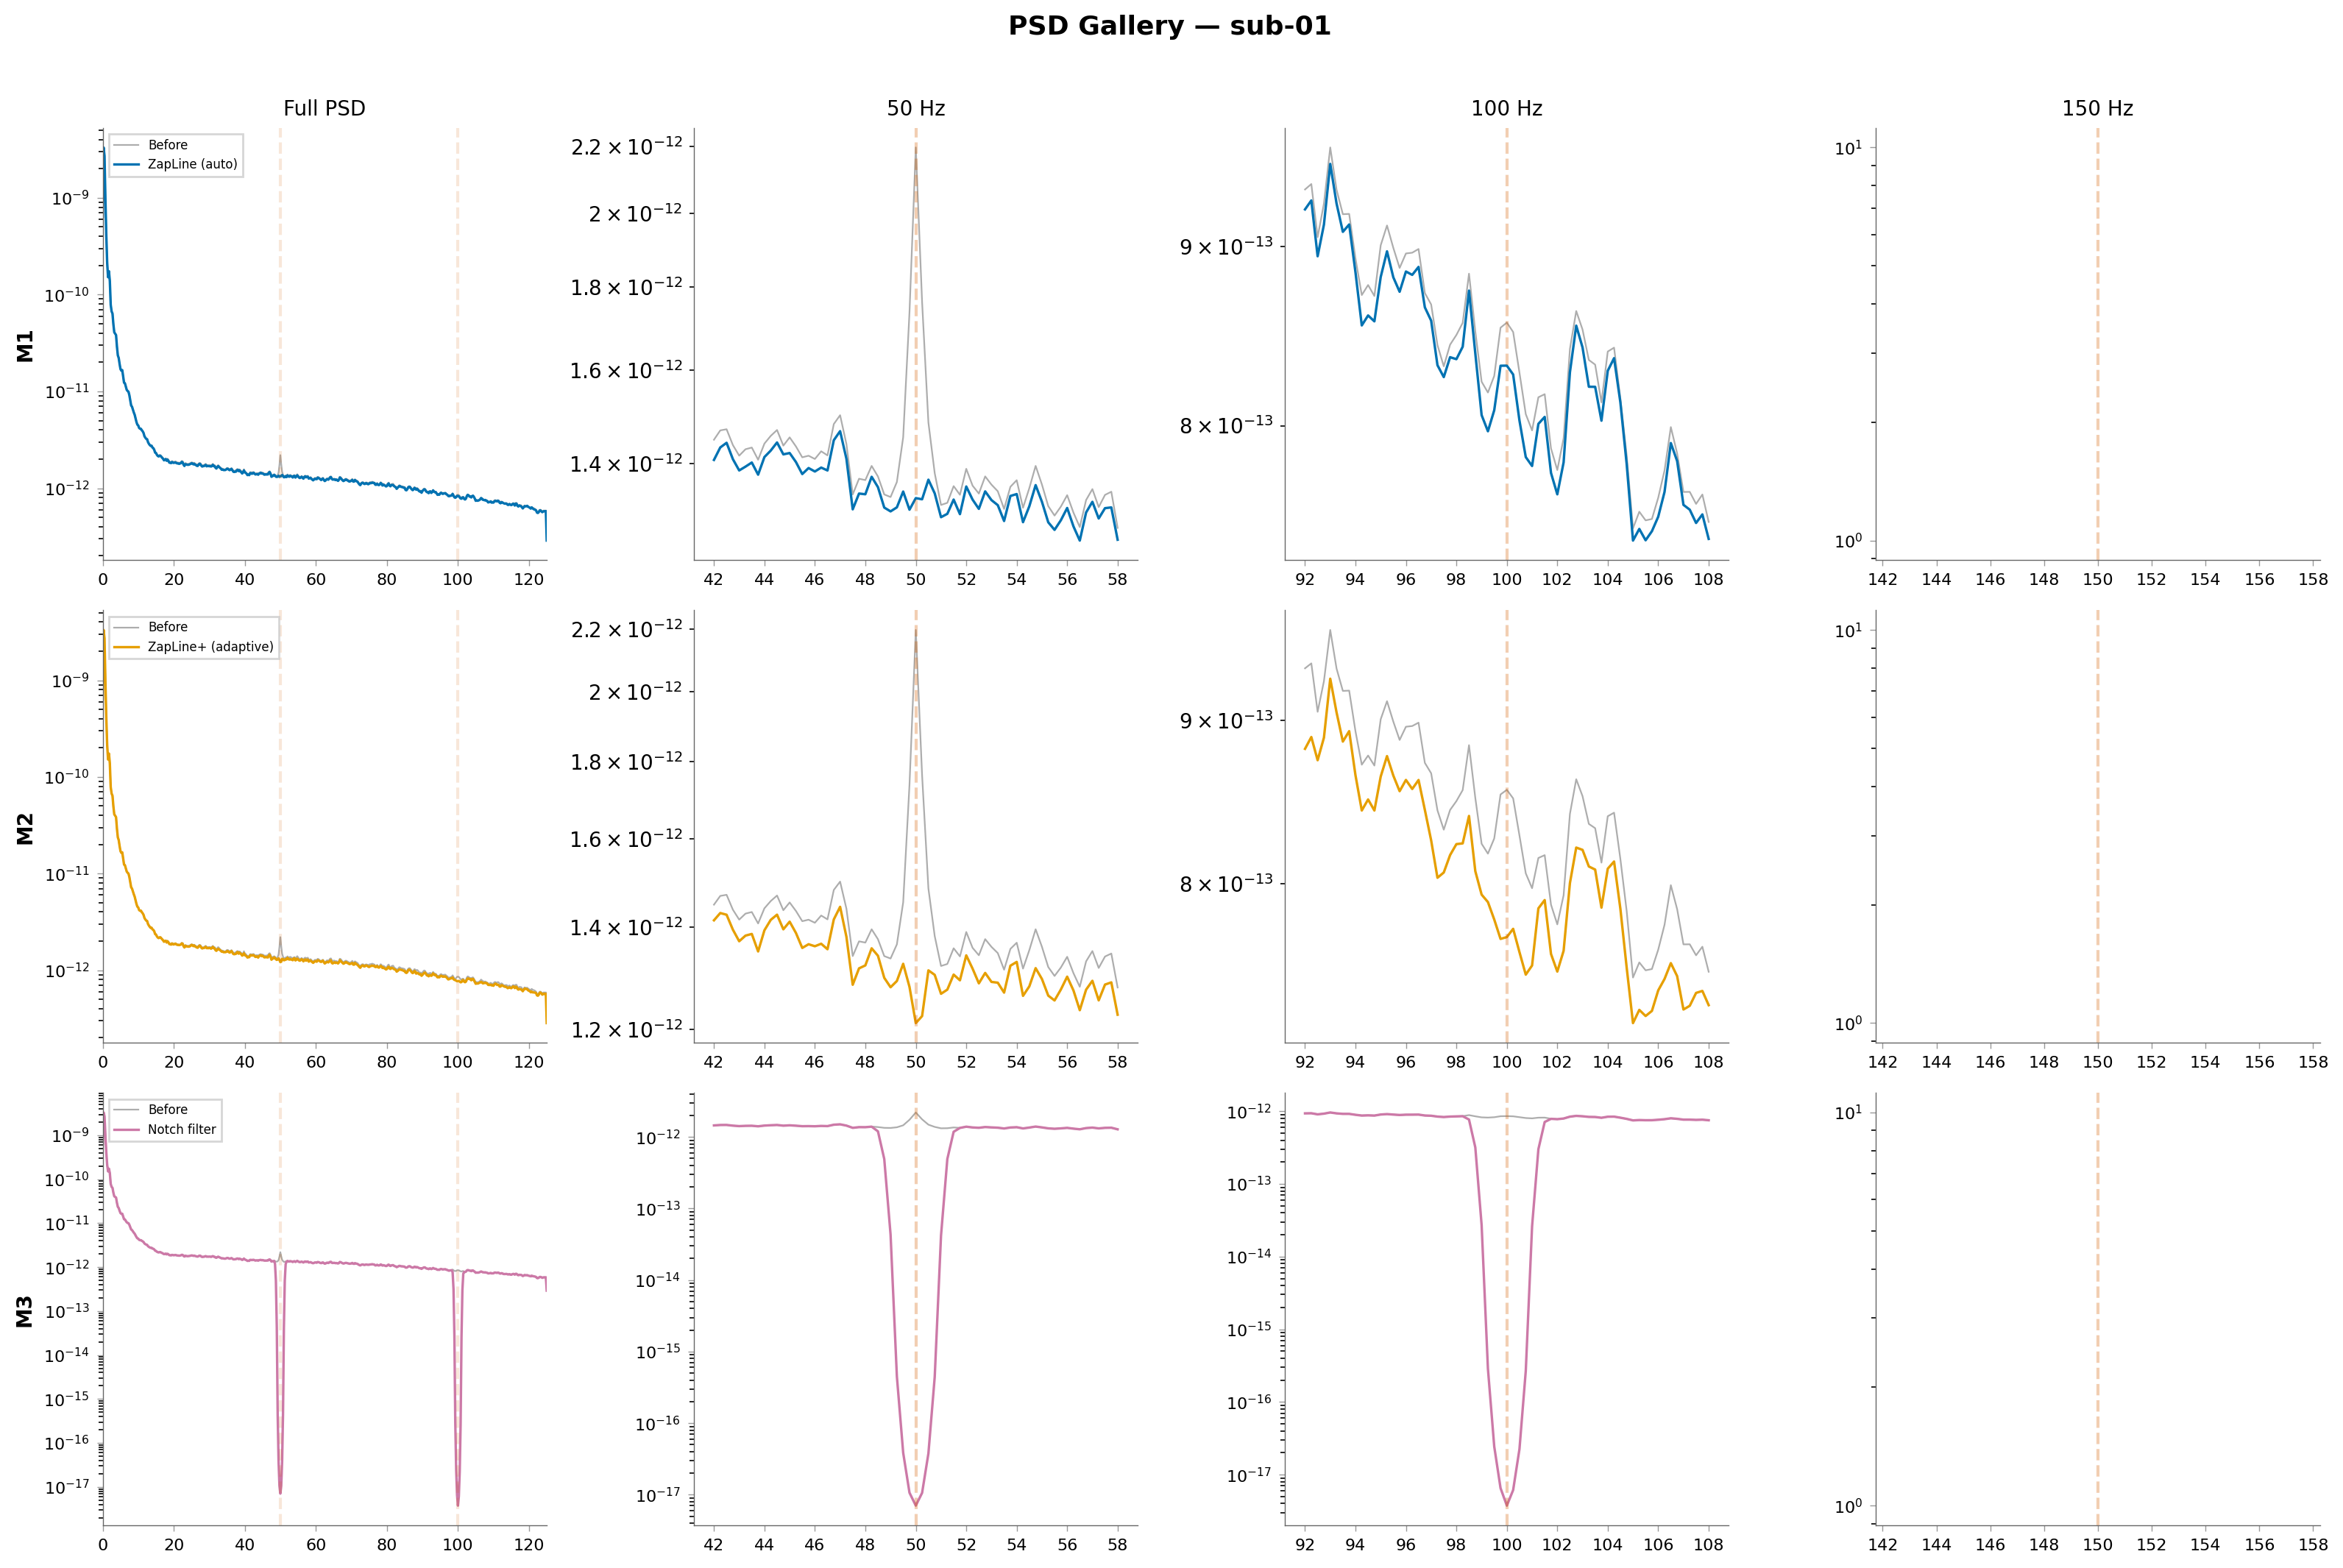

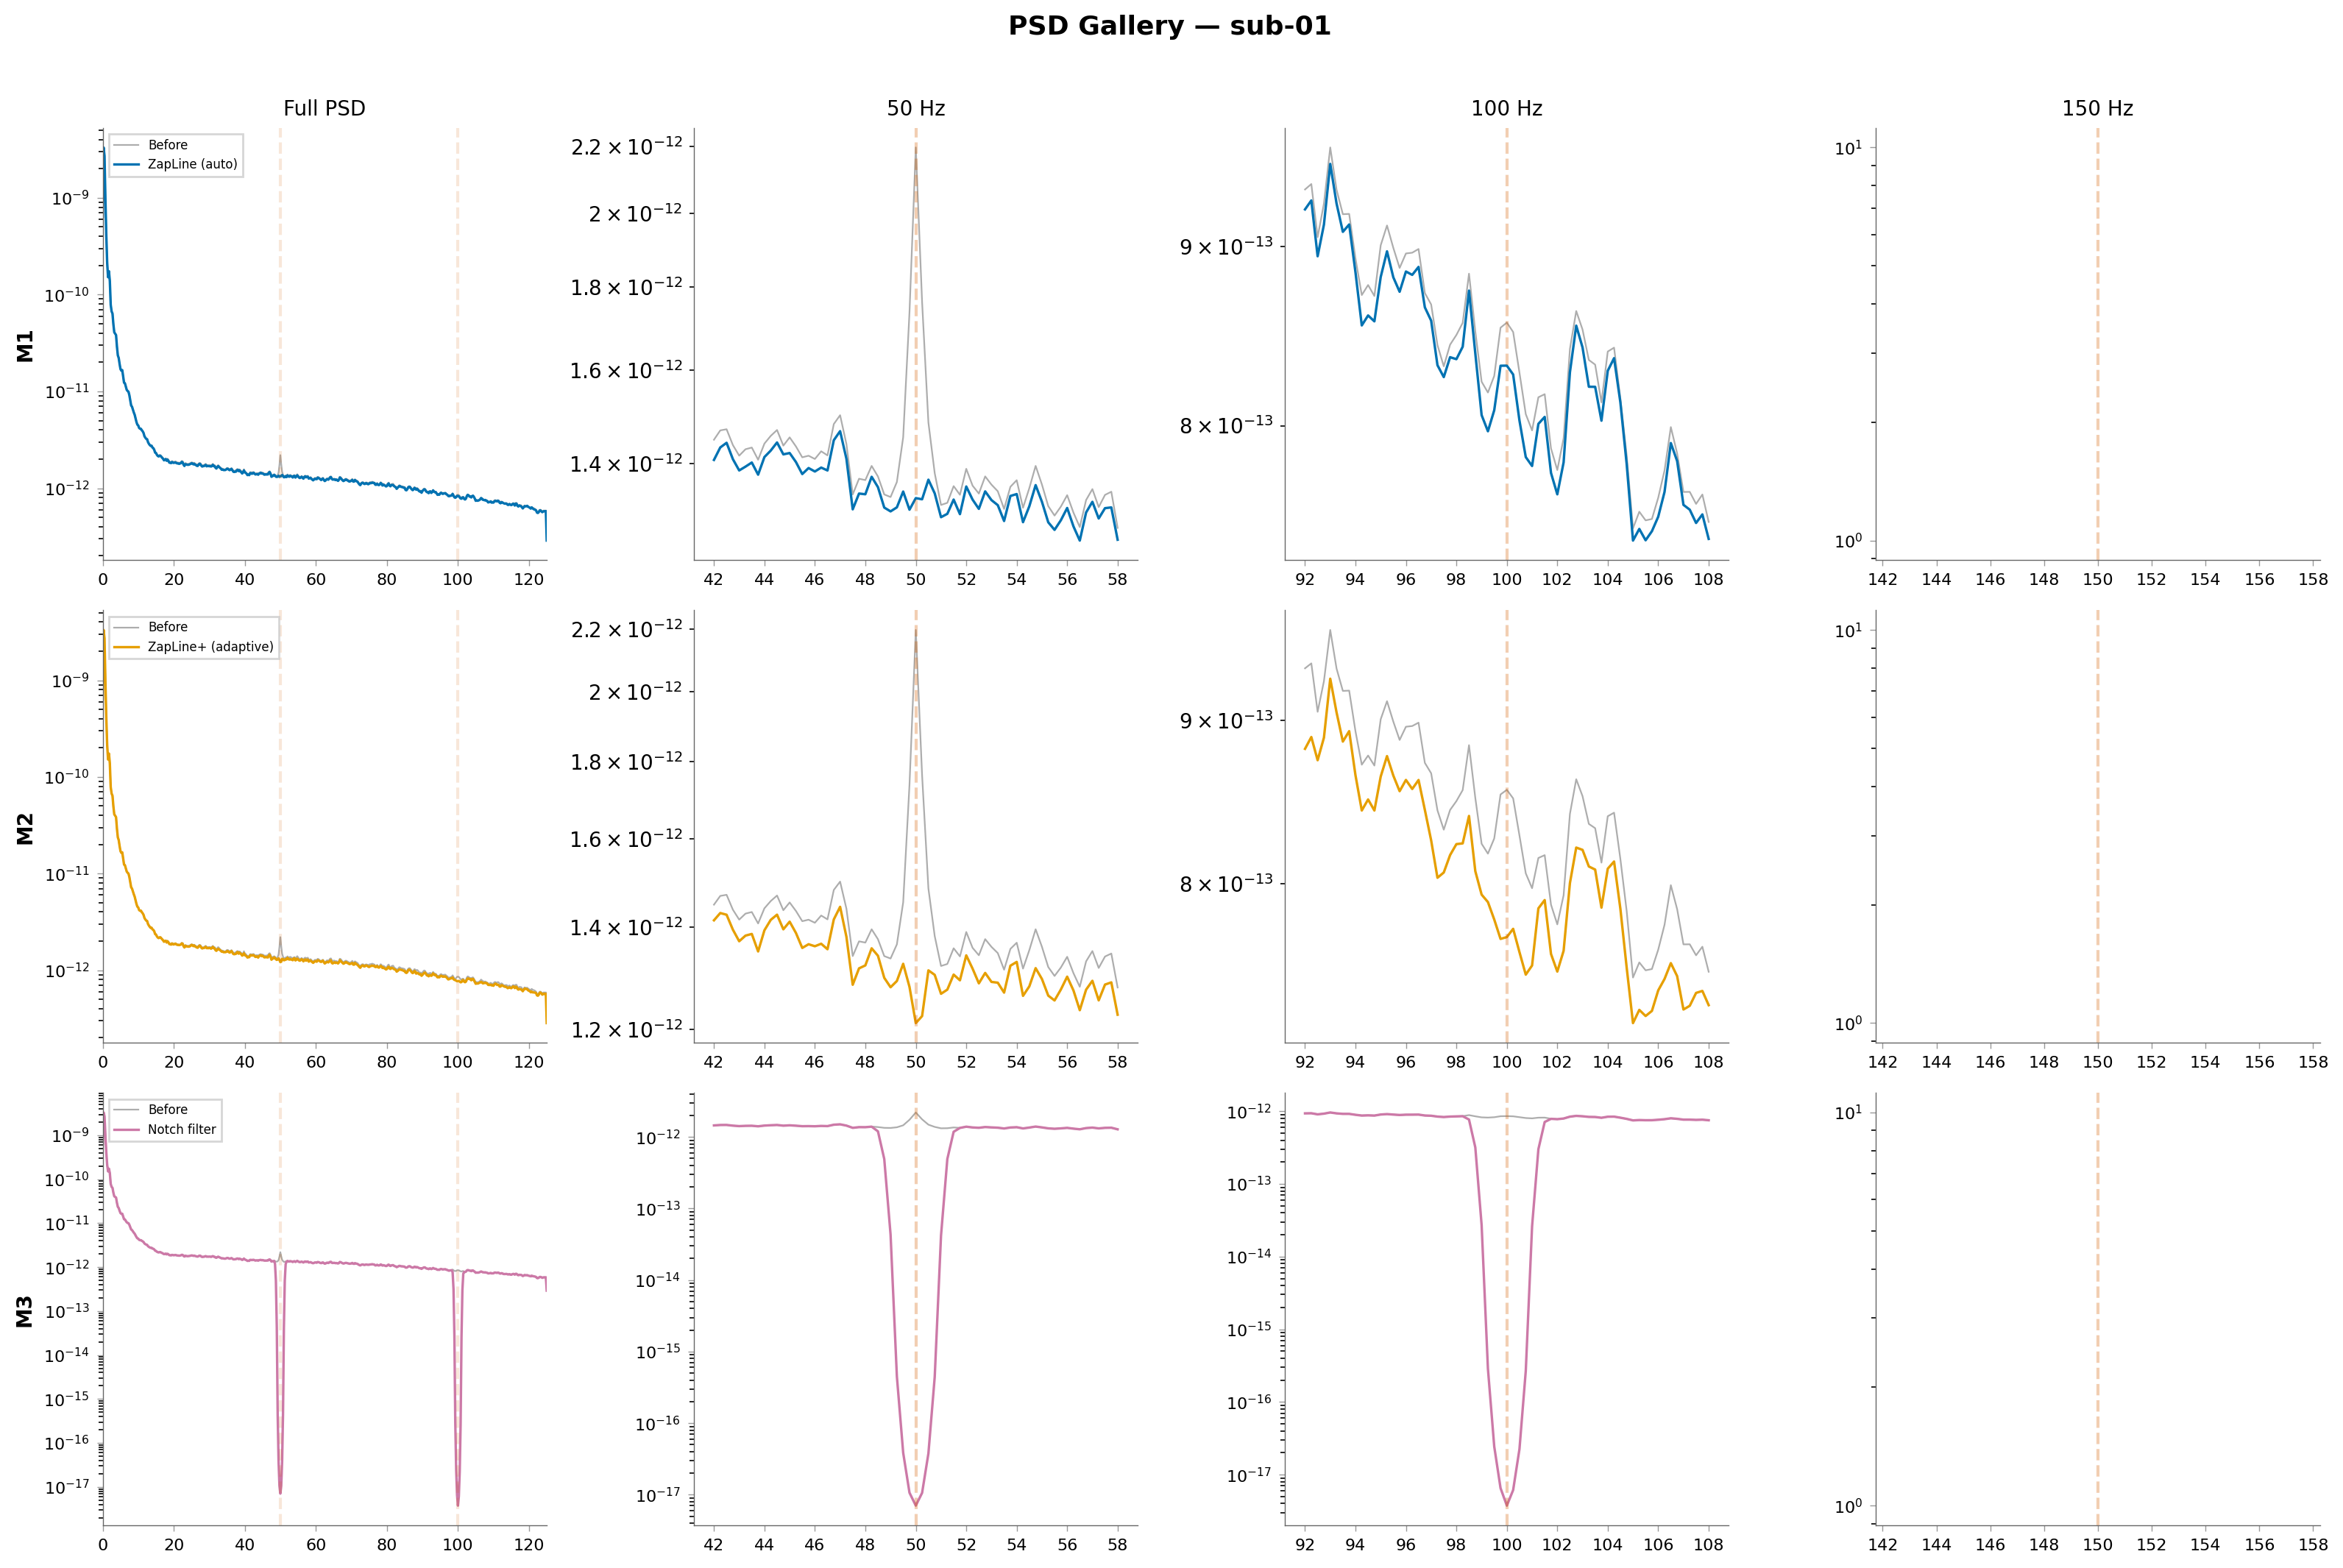

In [ ]:
# ── QA Step 1: PSD Gallery (full + harmonic zooms) per method ────────────────
sub_show = ALL_SUBJECTS[0]
harmonics_show = [LINE_FREQ * h for h in range(1, LINE_HARMONICS + 1)]

# Load baseline PSD
raw_base = load_and_preprocess(sub_show, DATA_ROOT)
freqs_base, gm_base = geometric_mean_psd(raw_base)

# Collect cleaned PSDs
cleaned_psds = {}
for mtag in METHOD_ORDER[1:]:  # skip M0
    raw_path = DERIV_ROOT / sub_show / "line_noise" / mtag / "cleaned_raw.fif"
    if raw_path.exists():
        raw_c = mne.io.read_raw_fif(str(raw_path), preload=True, verbose=False)
        cleaned_psds[mtag] = geometric_mean_psd(raw_c)
        del raw_c

del raw_base

# ── Save to group directory ──────────────────────────────────────────────────
GROUP_FIG_DIR = DERIV_ROOT / "group" / "line_noise"
GROUP_FIG_DIR.mkdir(parents=True, exist_ok=True)

plot_psd_gallery(
    freqs_base, gm_base, cleaned_psds,
    harmonics_hz=harmonics_show,
    fmax=PSD_FMAX,
    subject=sub_show,
    method_order=METHOD_ORDER[1:],
    method_colors=METHOD_COLORS,
    method_labels=METHOD_LABELS,
    save_path=GROUP_FIG_DIR / "psd_gallery.png",
    show=True,
)


### QA Step 2: Metric Comparison (whole-recording)

Bar charts comparing all methods across subjects for the whole recording.

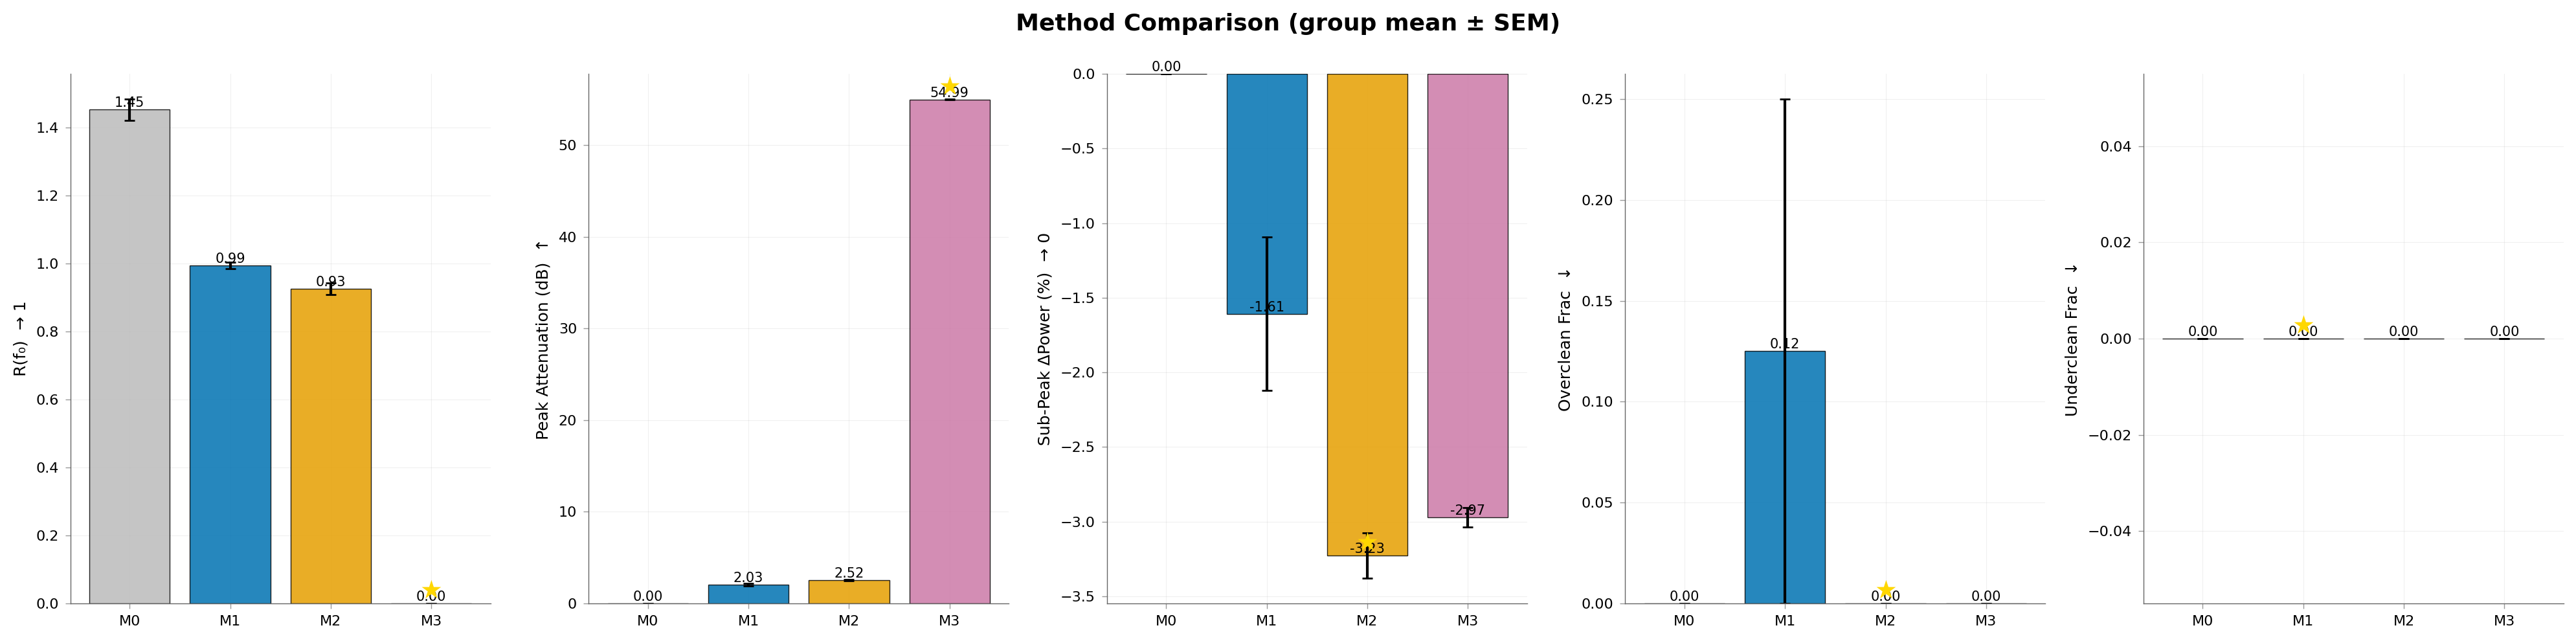

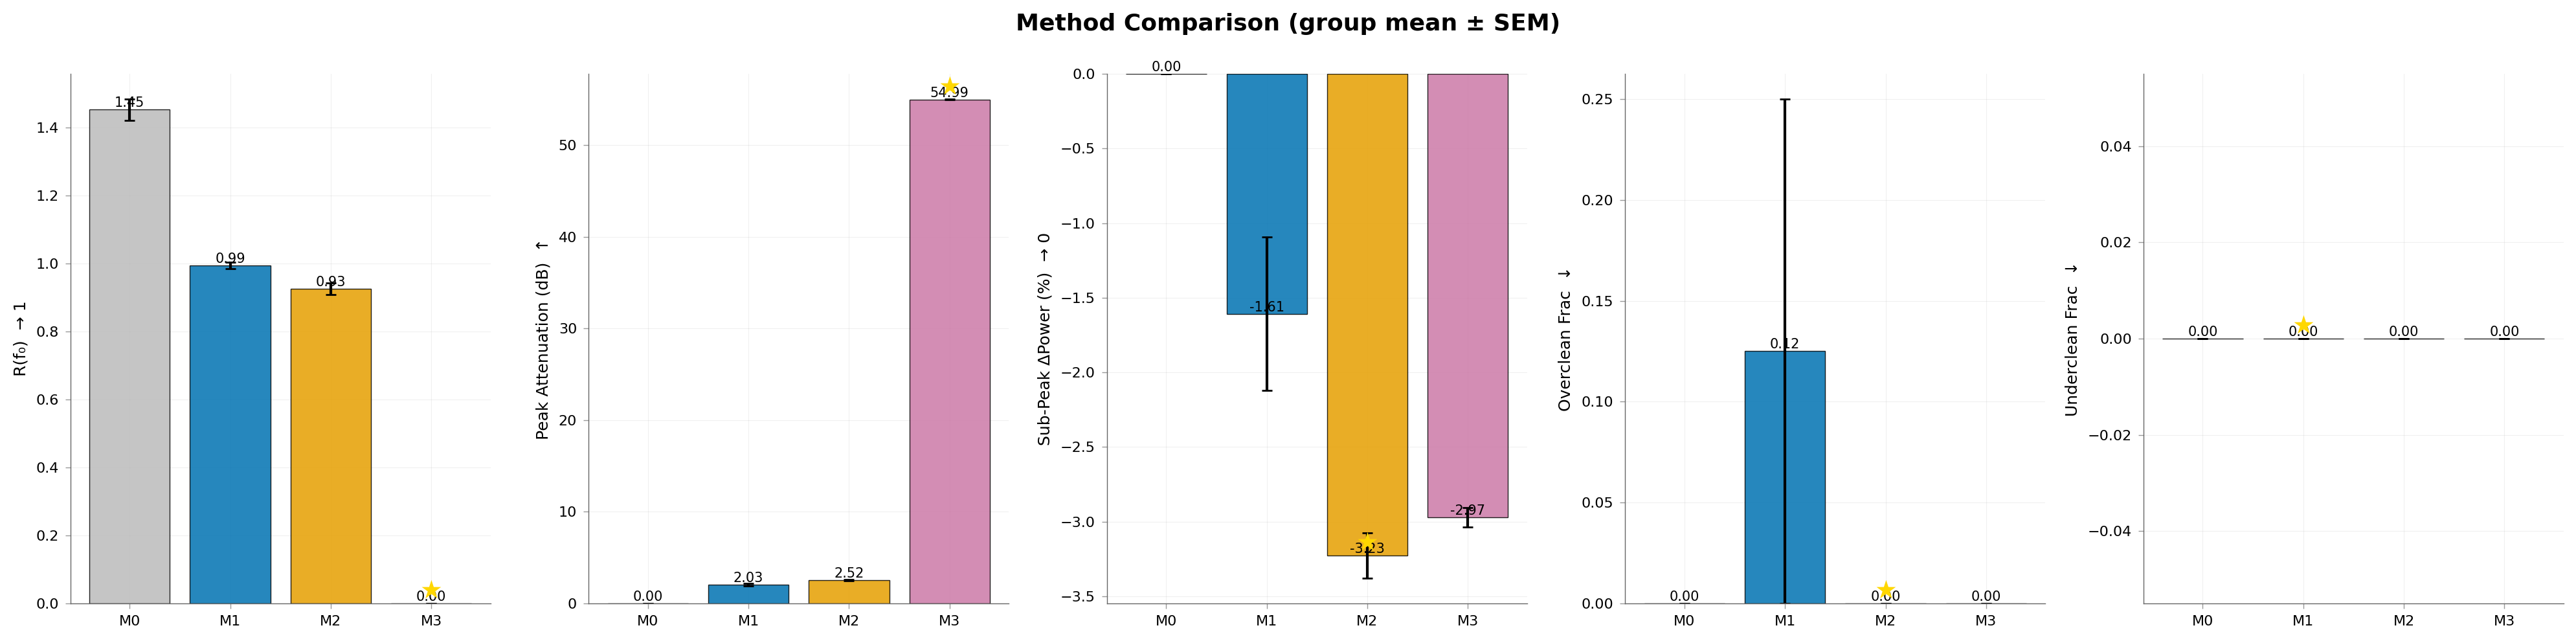

In [13]:
df_plot = df_all.dropna(subset=["peak_attenuation_db"])

# ── Bar chart: group mean ± SEM per method (whole-recording) ────────────────
plot_metric_bars(
    df_plot,
    method_order=METHOD_ORDER,
    method_colors=METHOD_COLORS,
    save_path=GROUP_FIG_DIR / "metric_bars.png",
    show=True,
)


In [14]:
# ── Summary Table (whole-recording) ──────────────────────────────────────────
metric_cols = [
    "R_f0",
    "peak_attenuation_db",
    "below_noise_pct",
    "overclean_proportion",
    "underclean_proportion",
]

print("\n" + "=" * 110)
print("SUMMARY TABLE — Line Noise Removal Benchmark (Whole Recording)")
print("=" * 110)

header = f"{'Method':<8}  {'R(f₀)':>8}  {'Atten(dB)':>10}  {'ΔPower(%)':>10}  {'Overclean':>10}  {'Underclean':>11}"
print(header)
print("-" * 110)

for mtag in METHOD_ORDER:
    sub_df = df_plot[df_plot["method"] == mtag]
    row = f"{mtag:<8}"
    for col in metric_cols:
        vals = sub_df[col].dropna()
        if len(vals) == 0:
            row += f"  {'N/A':>10}"
        elif len(vals) == 1:
            row += f"  {vals.iloc[0]:>10.3f}"
        else:
            row += f"  {vals.mean():>5.3f}±{vals.std():.3f}"
    print(row)

print("=" * 110)
print(f"N subjects = {df_plot['subject'].nunique()}")

# ── Summary Table (per-condition) ────────────────────────────────────────────
print("\n" + "=" * 110)
print("CONDITION-LEVEL R(f₀) — Method × Condition")
print("=" * 110)
header2 = f"{'Method':<8}"
for cond in CONDITIONS:
    header2 += f"  {CONDITION_LABELS[cond]:>20}"
print(header2)
print("-" * 110)

for mtag in METHOD_ORDER:
    row = f"{mtag:<8}"
    for cond in CONDITIONS:
        vals = df_cond[(df_cond["method"] == mtag) & (df_cond["condition"] == cond)]["R_f0"].dropna()
        if len(vals) == 0:
            row += f"  {'N/A':>20}"
        elif len(vals) == 1:
            row += f"  {vals.iloc[0]:>20.3f}"
        else:
            row += f"  {vals.mean():>10.3f}±{vals.std():<8.3f}"
    print(row)

print("=" * 110)

# ── Parameter Table ──────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("PARAMETER TABLE")
print("=" * 80)
print(f"{'Method':<8}  {'Description':<35}  {'Key Parameters'}")
print("-" * 80)
for mtag in METHOD_ORDER:
    desc = METHOD_LABELS[mtag]
    if mtag == "M0":
        params = "—"
    elif mtag == "M1":
        params = f"n_remove=auto, n_harmonics={LINE_HARMONICS}"
    elif mtag == "M2":
        params = f"adaptive=True, sigma=3.0, min_remove=1, max_prop=0.2"
    elif mtag == "M3":
        params = f"notch_widths=2.0 Hz, method=fir, freqs={LINE_FREQ}+harmonics"
    print(f"{mtag:<8}  {desc:<35}  {params}")
print("=" * 80)


SUMMARY TABLE — Line Noise Removal Benchmark (Whole Recording)
Method       R(f₀)   Atten(dB)   ΔPower(%)   Overclean   Underclean
--------------------------------------------------------------------------------------------------------------
M0        1.453±0.044  0.000±0.000  0.000±0.000  0.000±0.000  0.000±0.000
M1        0.995±0.013  2.030±0.194  -1.607±0.727  0.125±0.177  0.000±0.000
M2        0.926±0.024  2.516±0.098  -3.226±0.215  0.000±0.000  0.000±0.000
M3        0.001±0.000  54.993±0.076  -2.971±0.092  0.000±0.000  0.000±0.000
N subjects = 2

CONDITION-LEVEL R(f₀) — Method × Condition
Method            Lab (seated)        Oval (walking)      Campus (walking)
--------------------------------------------------------------------------------------------------------------
M0             1.854±0.346          1.319±0.004          1.452±0.336   
M1             0.969±0.055          1.050±0.032          1.002±0.061   
M2             0.913±0.042          0.938±0.021          0.925±0.078

### QA Step 2c: Attenuation vs Sub-Peak Distortion Trade-off (whole-recording)

The ideal method sits in the **upper-centre**: high attenuation, ΔPower near 0%.

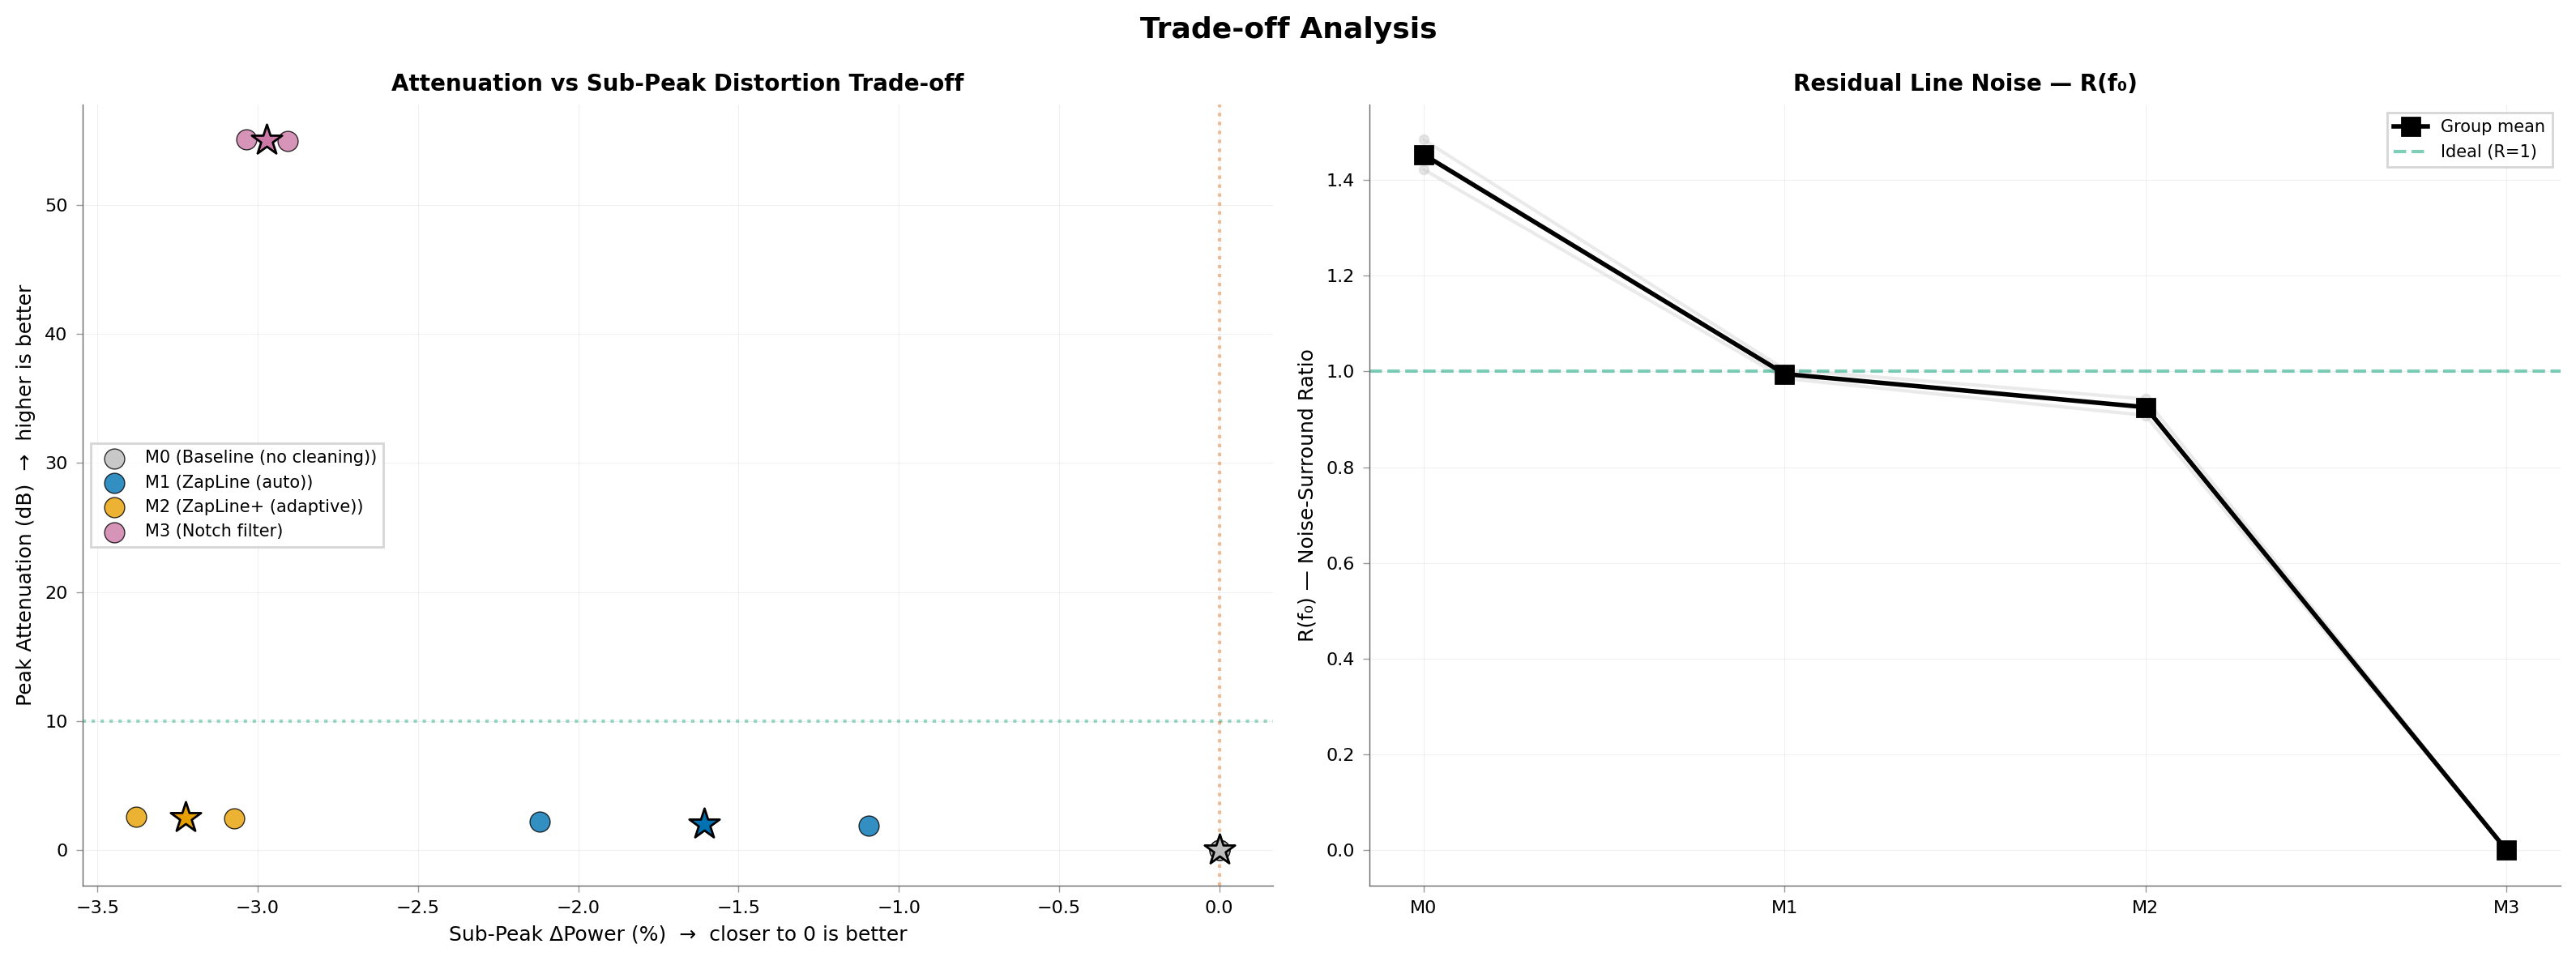

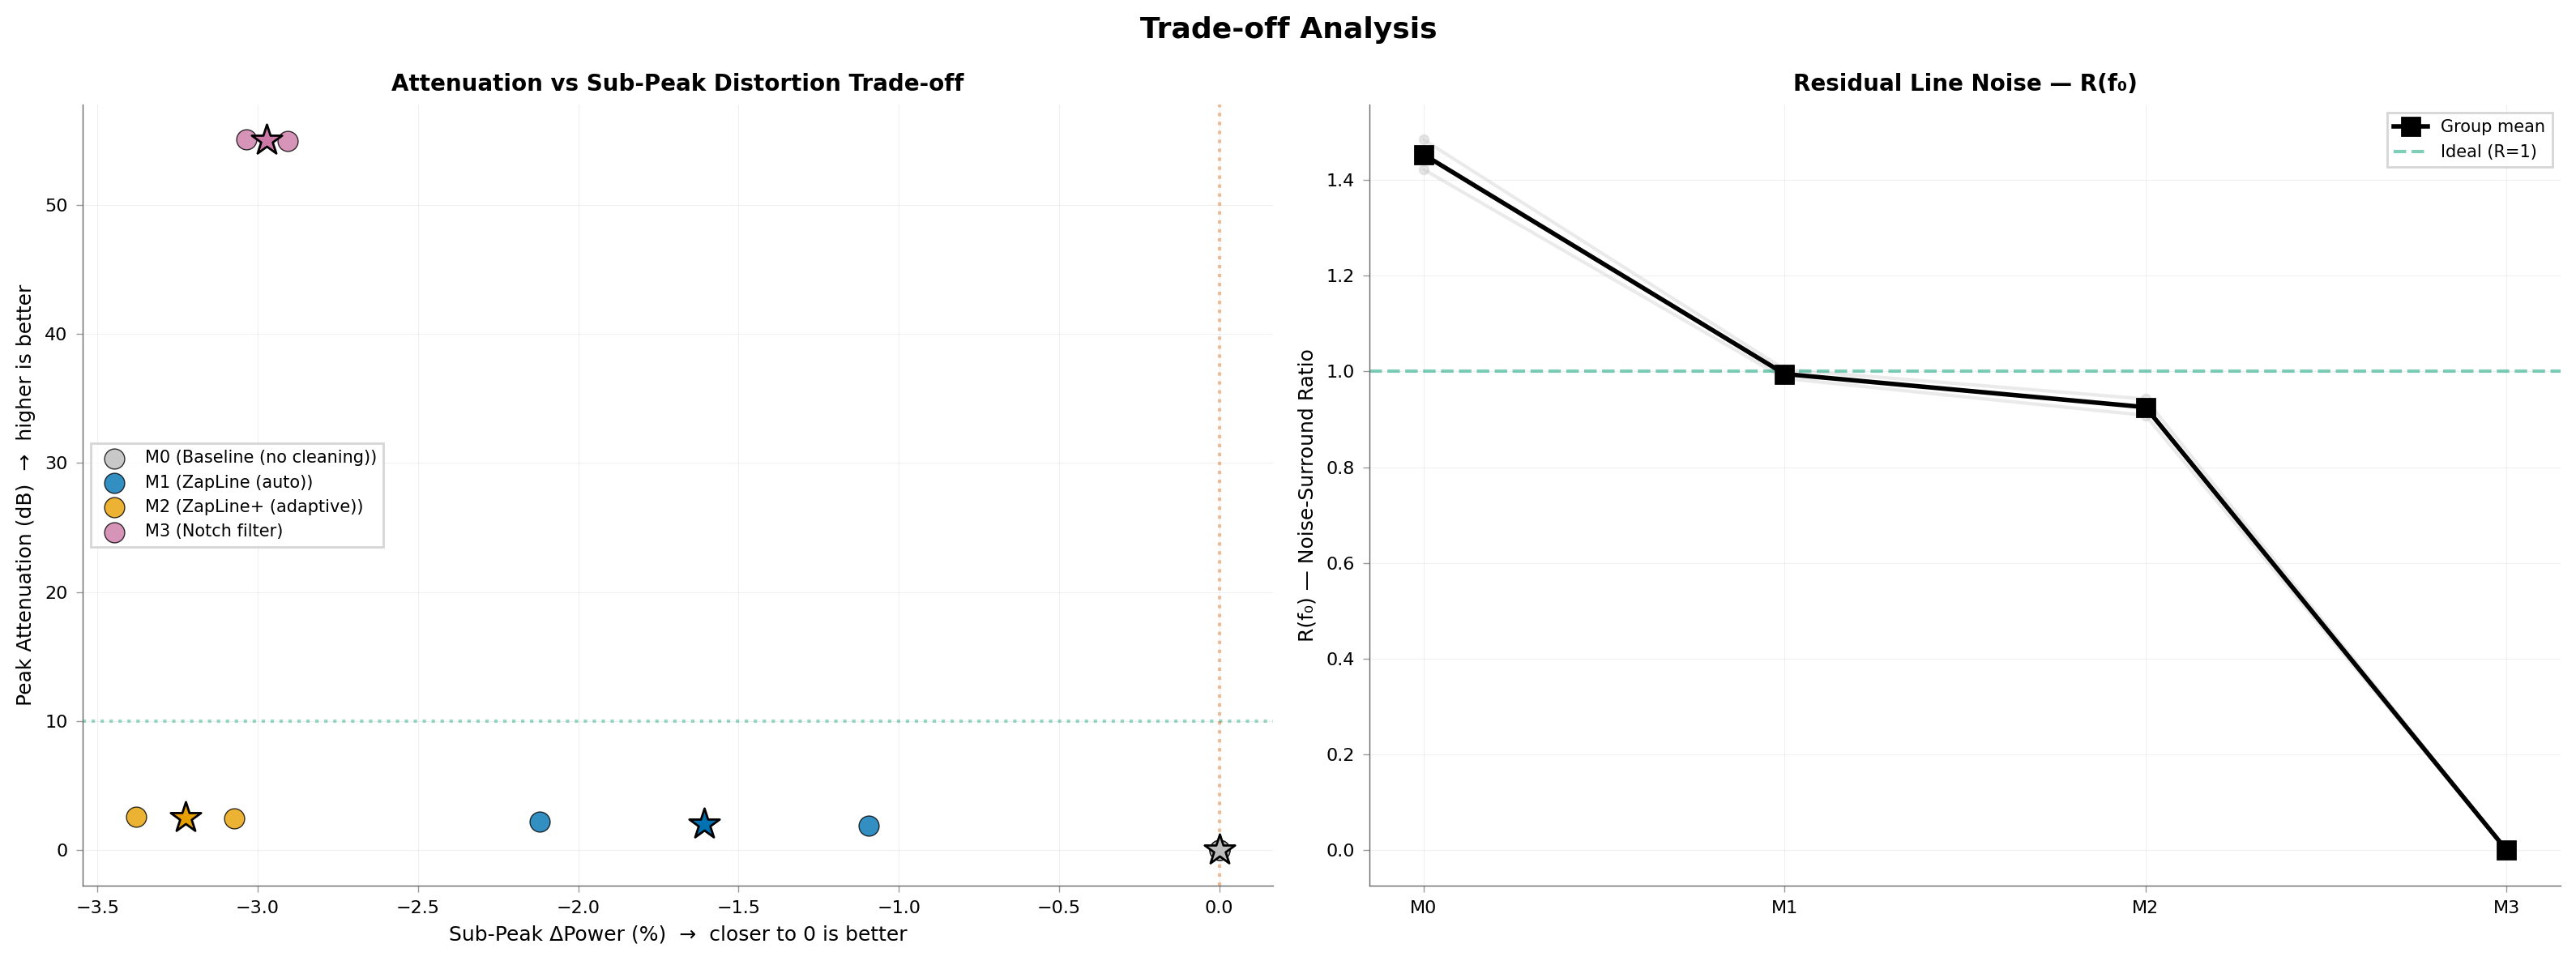

In [15]:
# ── Attenuation-vs-Distortion + R(f₀) (whole-recording) ─────────────────────
plot_tradeoff_and_r(
    df_plot,
    method_order=METHOD_ORDER,
    method_colors=METHOD_COLORS,
    method_labels=METHOD_LABELS,
    save_path=GROUP_FIG_DIR / "tradeoff_and_r.png",
    show=True,
)


### QA Step 3: Paired Comparison & Per-Harmonic Attenuation

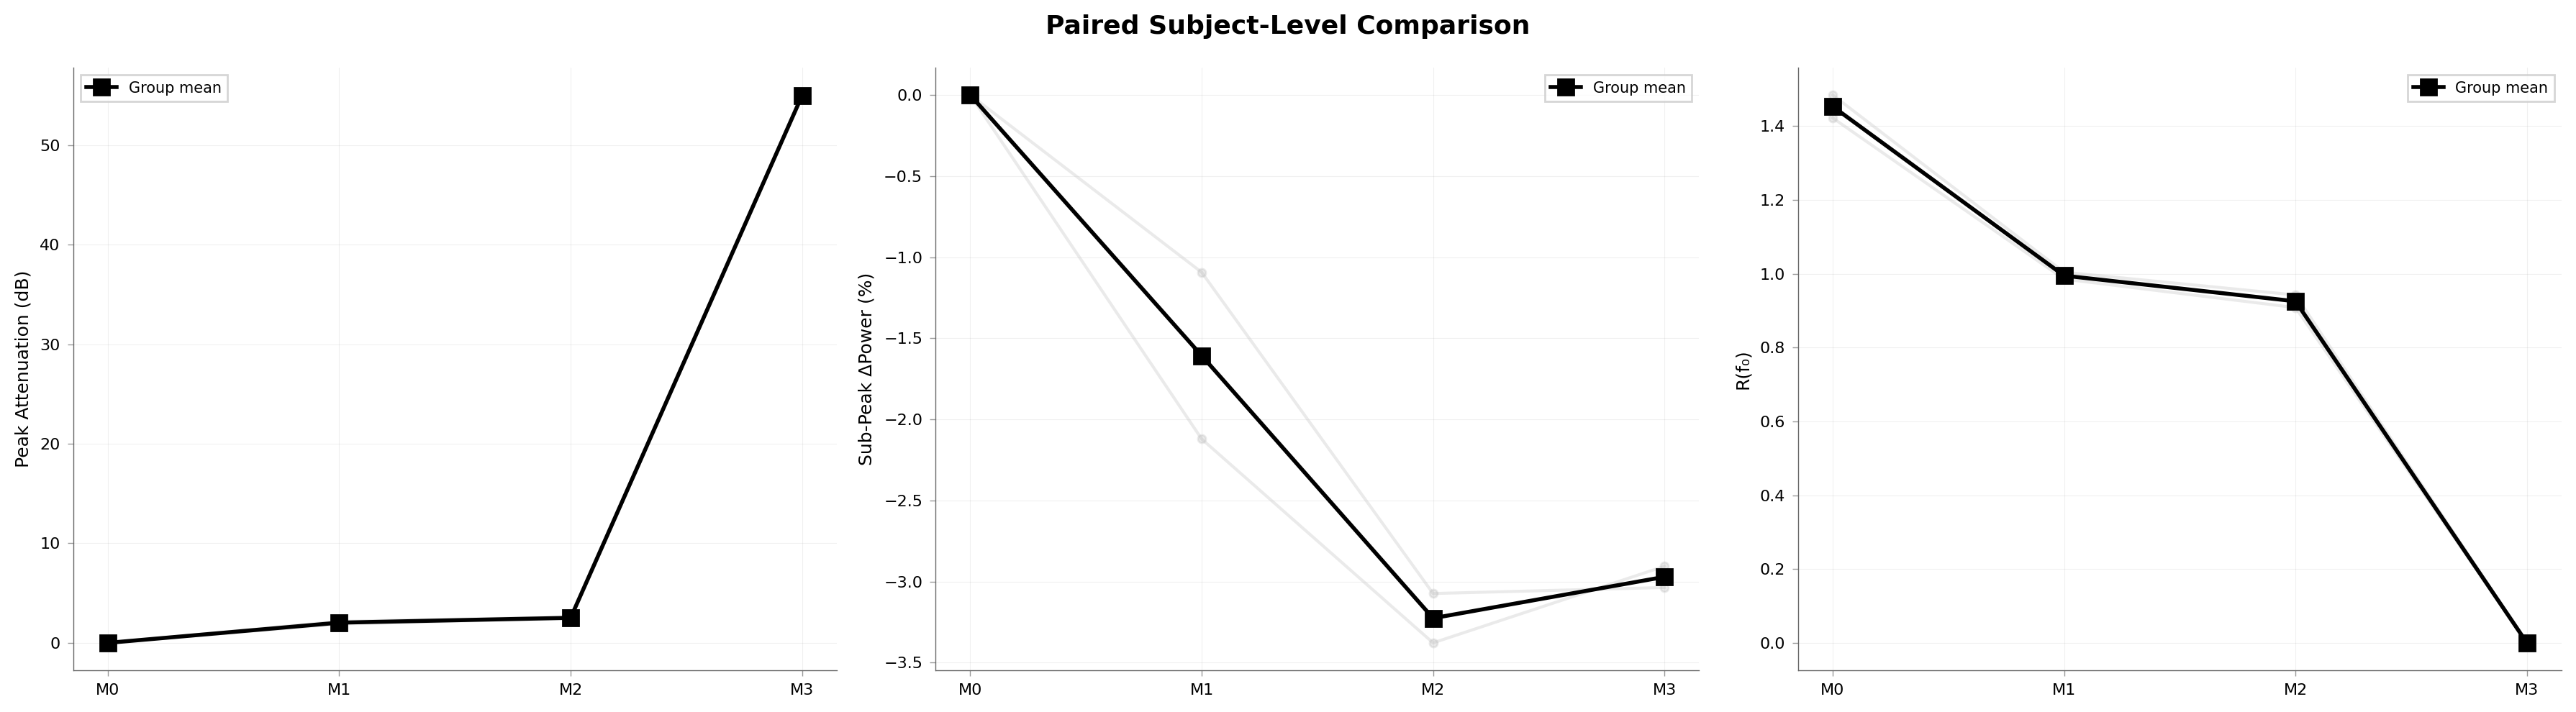

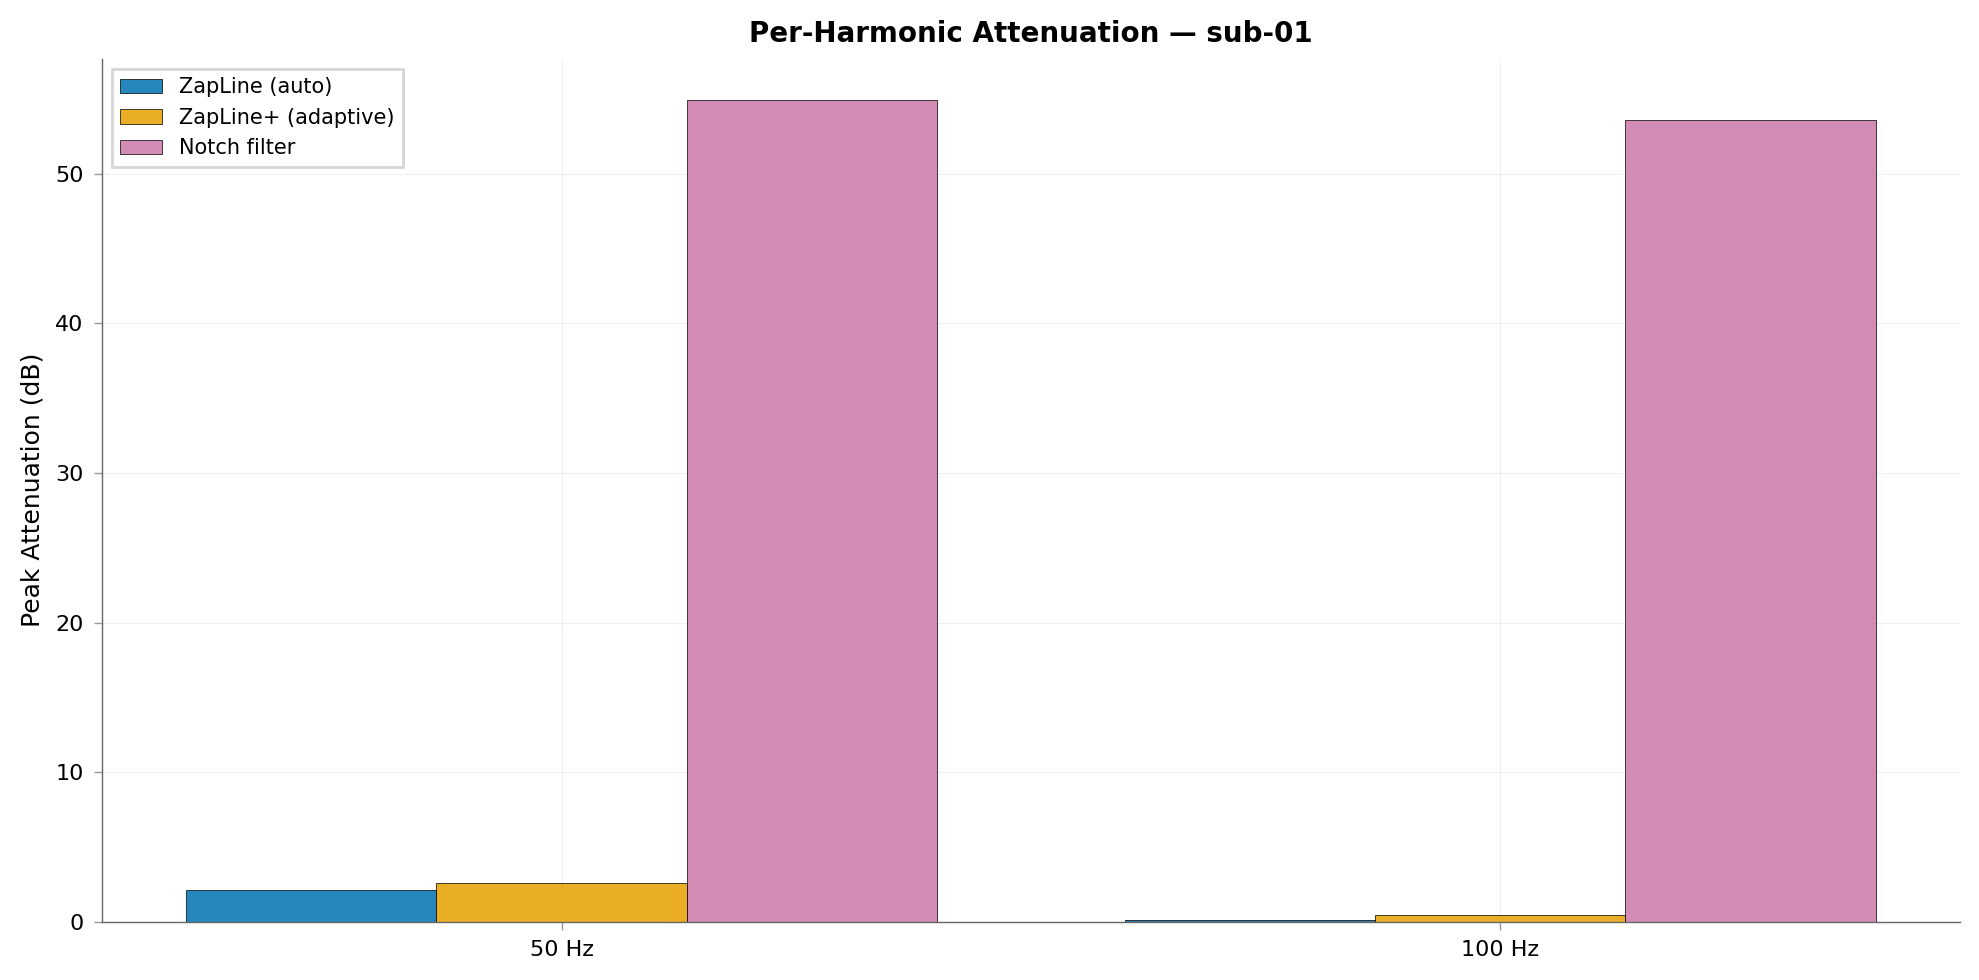

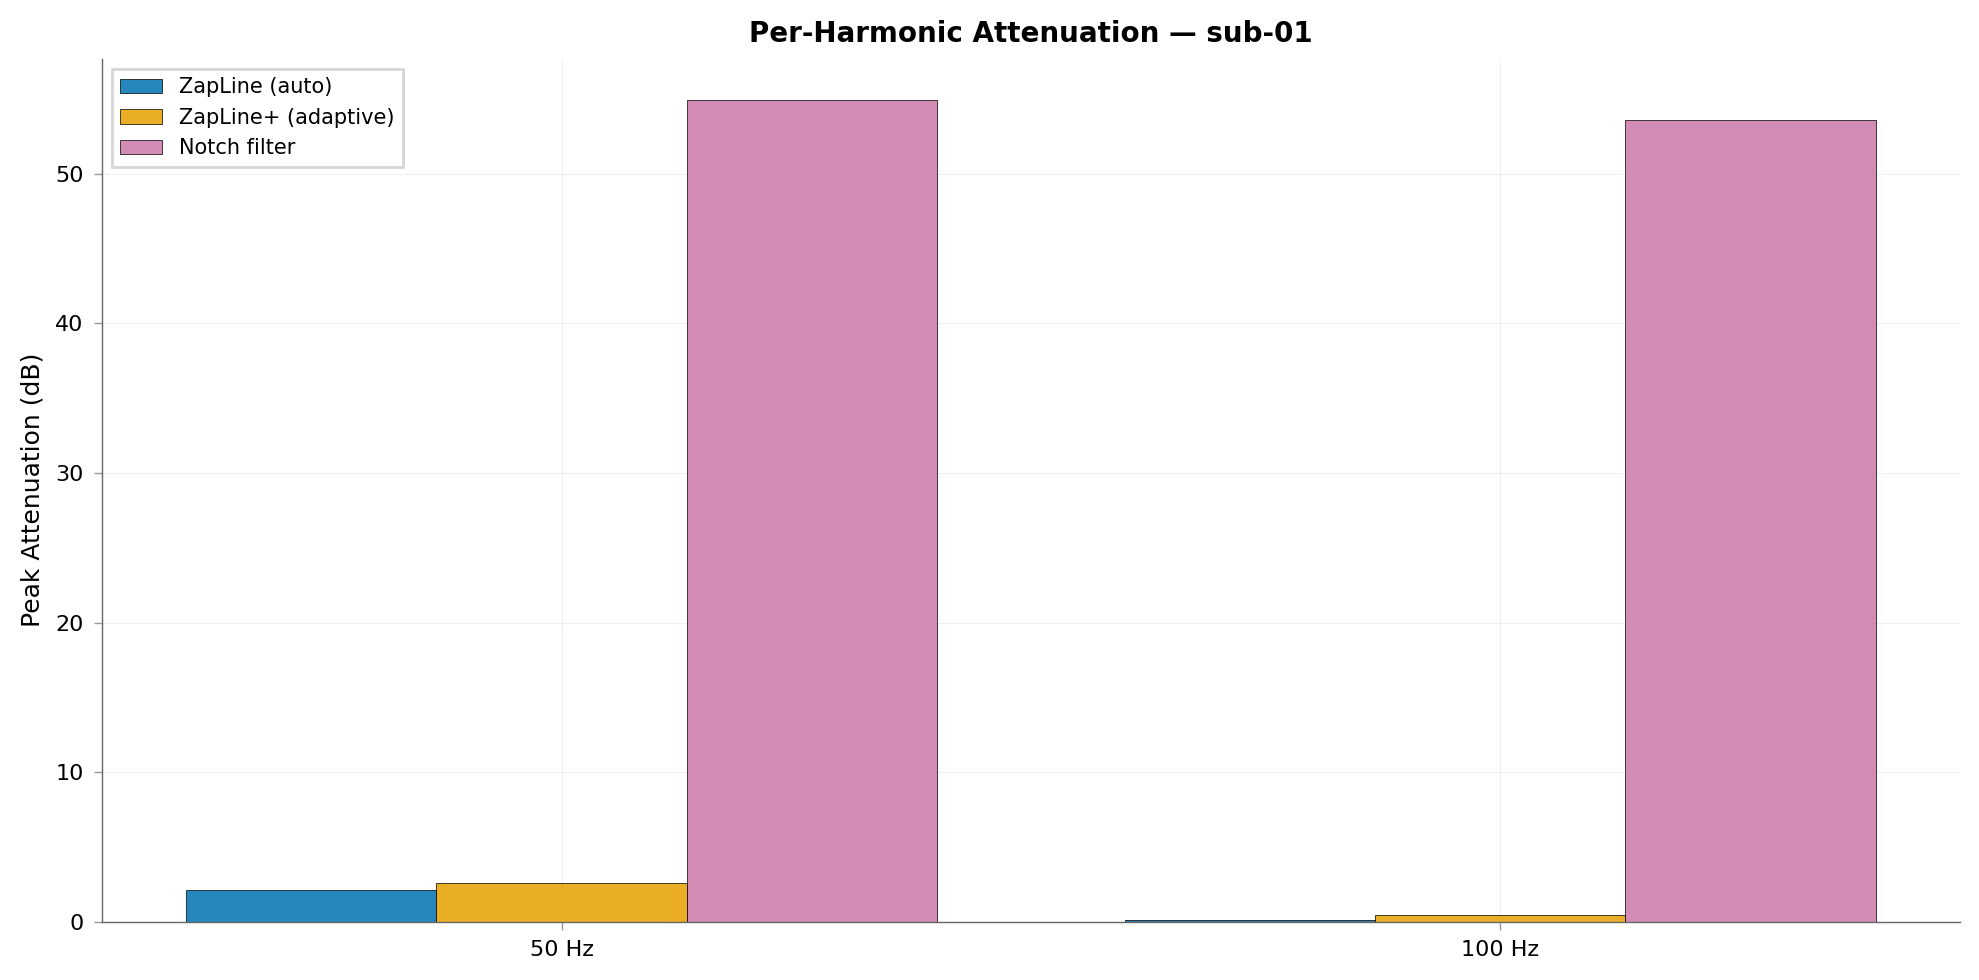

In [16]:
# ── Paired subject-level comparison (multi-subject only) ─────────────────────
fig_paired = plot_paired_metrics(
    df_plot,
    method_order=METHOD_ORDER,
    method_colors=METHOD_COLORS,
    save_path=GROUP_FIG_DIR / "paired_metrics.png" if df_plot["subject"].nunique() > 1 else None,
    show=True,
)
if fig_paired is None:
    print("Only 1 subject — paired comparison requires ≥ 2 subjects.")

# ── Per-harmonic attenuation bar chart ───────────────────────────────────────
sub_h = ALL_SUBJECTS[0]
raw_base_h = load_and_preprocess(sub_h, DATA_ROOT)
freqs_base_h, gm_base_h = geometric_mean_psd(raw_base_h)

harmonics_hz = [LINE_FREQ * h for h in range(1, LINE_HARMONICS + 1)
                if LINE_FREQ * h < freqs_base_h[-1]]

cleaned_psds_h = {}
for mtag in METHOD_ORDER[1:]:  # skip M0
    raw_path = DERIV_ROOT / sub_h / "line_noise" / mtag / "cleaned_raw.fif"
    if raw_path.exists():
        raw_c = mne.io.read_raw_fif(str(raw_path), preload=True, verbose=False)
        cleaned_psds_h[mtag] = geometric_mean_psd(raw_c)
        del raw_c
del raw_base_h

plot_harmonic_attenuation(
    freqs_base_h, gm_base_h, cleaned_psds_h,
    harmonics_hz=harmonics_hz,
    subject=sub_h,
    method_order=METHOD_ORDER[1:],
    method_colors=METHOD_COLORS,
    method_labels=METHOD_LABELS,
    save_path=GROUP_FIG_DIR / "harmonic_attenuation.png",
    show=True,
)


## 12 — Condition-Level Analysis

The key question: **how does each denoising method perform under different
mobility conditions?**

- **Lab (seated)**: Stable line noise, low non-stationarity → all methods expected to work well
- **Oval (walking, field)**: Moderate non-stationarity from rhythmic gait + EMI variation
- **Campus (walking, path)**: High non-stationarity from variable terrain + environmental EMI

Adaptive methods (M2) should excel under high non-stationarity, while simpler
methods (M3 notch) may struggle with frequency drift and amplitude modulation.

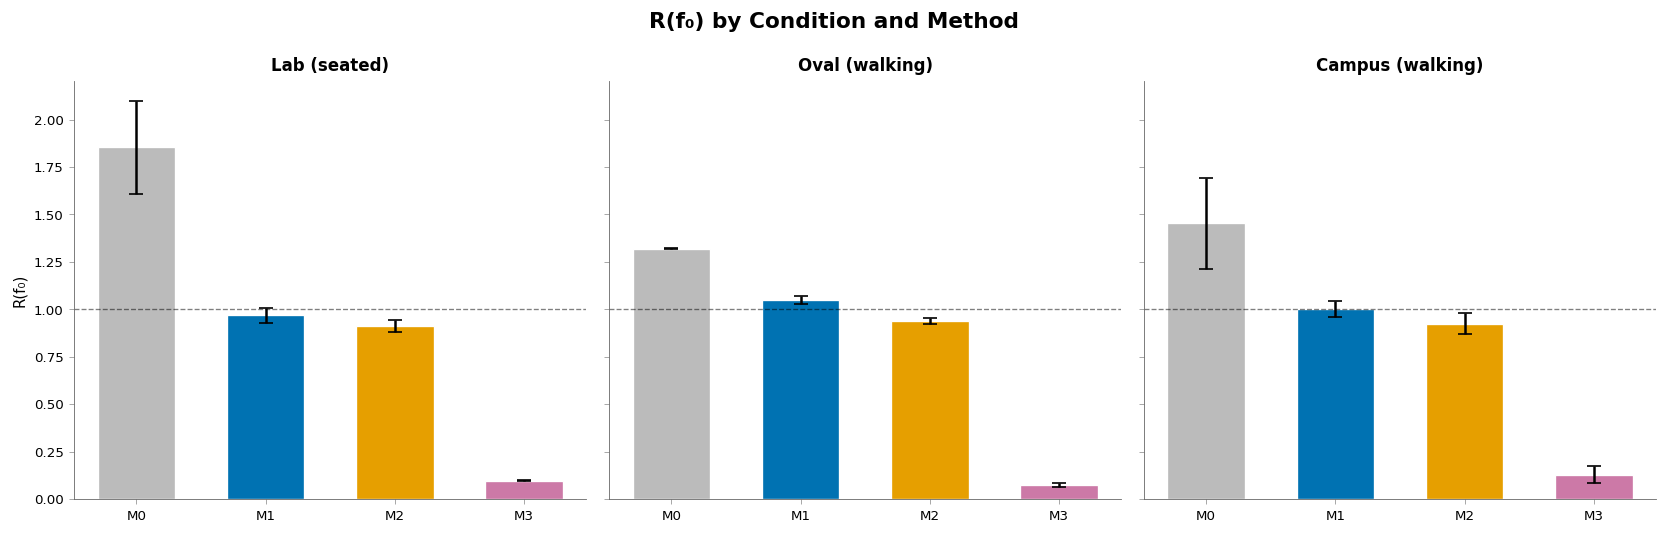

In [17]:
# ── Condition × Method: R(f₀) grouped bar chart ─────────────────────────────
from mne_denoise.viz._theme import pub_figure, style_axes, pub_legend, COLORS, FONTS

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fig.suptitle("R(f₀) by Condition and Method", fontsize=FONTS["suptitle"], fontweight="bold")

bar_width = 0.2
x = np.arange(len(METHOD_ORDER))

for ax_idx, cond in enumerate(CONDITIONS):
    ax = axes[ax_idx]
    cond_data = df_cond[df_cond["condition"] == cond]

    means = []
    sems = []
    for mtag in METHOD_ORDER:
        vals = cond_data[cond_data["method"] == mtag]["R_f0"].dropna()
        means.append(vals.mean() if len(vals) > 0 else 0)
        sems.append(vals.sem() if len(vals) > 1 else 0)

    bars = ax.bar(x, means, bar_width * 3,
                  yerr=sems, capsize=4,
                  color=[METHOD_COLORS[m] for m in METHOD_ORDER],
                  edgecolor="white", linewidth=0.8)

    ax.set_title(CONDITION_LABELS[cond], fontsize=FONTS["title"], fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, fontsize=FONTS["tick"])
    ax.axhline(1.0, color="k", linestyle="--", linewidth=0.8, alpha=0.5, label="Ideal R=1")

    if ax_idx == 0:
        ax.set_ylabel("R(f₀)", fontsize=FONTS["label"])
    style_axes(ax)

# Show the "Ideal R=1" reference in the legend
pub_legend(axes[0], loc="upper right")

fig.tight_layout()
fig.savefig(GROUP_FIG_DIR / "condition_r_f0_bars.png", dpi=300, bbox_inches="tight")
plt.show()


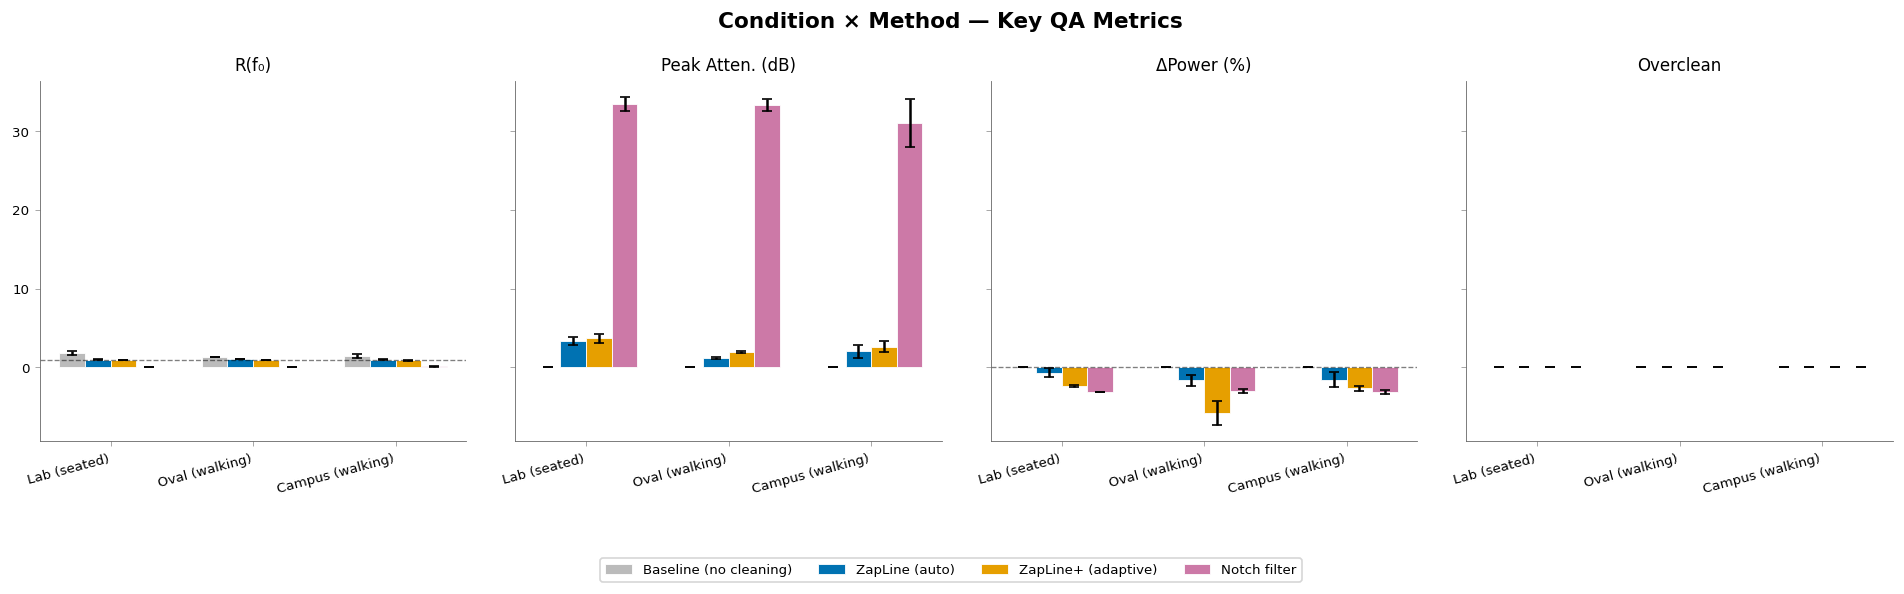

In [18]:
# ── Condition × Method: All key metrics heatmap ─────────────────────────────
cond_metrics_to_show = ["R_f0", "peak_attenuation_db", "below_noise_pct", "overclean_proportion"]
cond_metric_labels = {
    "R_f0": "R(f₀)",
    "peak_attenuation_db": "Peak Atten. (dB)",
    "below_noise_pct": "ΔPower (%)",
    "overclean_proportion": "Overclean",
}

fig, axes = plt.subplots(1, len(cond_metrics_to_show), figsize=(16, 4.5), sharey=False)
fig.suptitle("Condition × Method — Key QA Metrics",
             fontsize=FONTS["suptitle"], fontweight="bold")

for ax_idx, metric in enumerate(cond_metrics_to_show):
    ax = axes[ax_idx]
    x = np.arange(len(CONDITIONS))
    bar_width = 0.18

    for m_idx, mtag in enumerate(METHOD_ORDER):
        vals_per_cond = []
        errs_per_cond = []
        for cond in CONDITIONS:
            v = df_cond[(df_cond["method"] == mtag) & (df_cond["condition"] == cond)][metric].dropna()
            vals_per_cond.append(v.mean() if len(v) > 0 else 0)
            errs_per_cond.append(v.sem() if len(v) > 1 else 0)

        offset = (m_idx - len(METHOD_ORDER) / 2 + 0.5) * bar_width
        ax.bar(x + offset, vals_per_cond, bar_width,
               yerr=errs_per_cond, capsize=3,
               color=METHOD_COLORS[mtag], label=METHOD_LABELS[mtag] if ax_idx == 0 else "",
               edgecolor="white", linewidth=0.5)

    ax.set_title(cond_metric_labels[metric], fontsize=FONTS["title"])
    ax.set_xticks(x)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS],
                       fontsize=FONTS["tick"], rotation=15, ha="right")

    # Add ideal reference lines
    if metric == "R_f0":
        ax.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
    elif metric == "below_noise_pct":
        ax.axhline(0.0, color="k", ls="--", lw=0.8, alpha=0.5)

    style_axes(ax)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(METHOD_ORDER),
           bbox_to_anchor=(0.5, -0.02), fontsize=FONTS["legend"],
           frameon=False, handlelength=1.2, handletextpad=0.5)
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(GROUP_FIG_DIR / "condition_metrics_grouped.png", dpi=300, bbox_inches="tight")
plt.show()


### Condition-Level PSD Comparison

Show the geometric-mean PSD for each condition (before/after) for the first subject.
This reveals how line noise varies across conditions and how each method handles it.

  sub-01 lab: 5 block(s), 858 s total
  sub-01 oval: 5 block(s), 863 s total
  sub-01 campus: 5 block(s), 858 s total


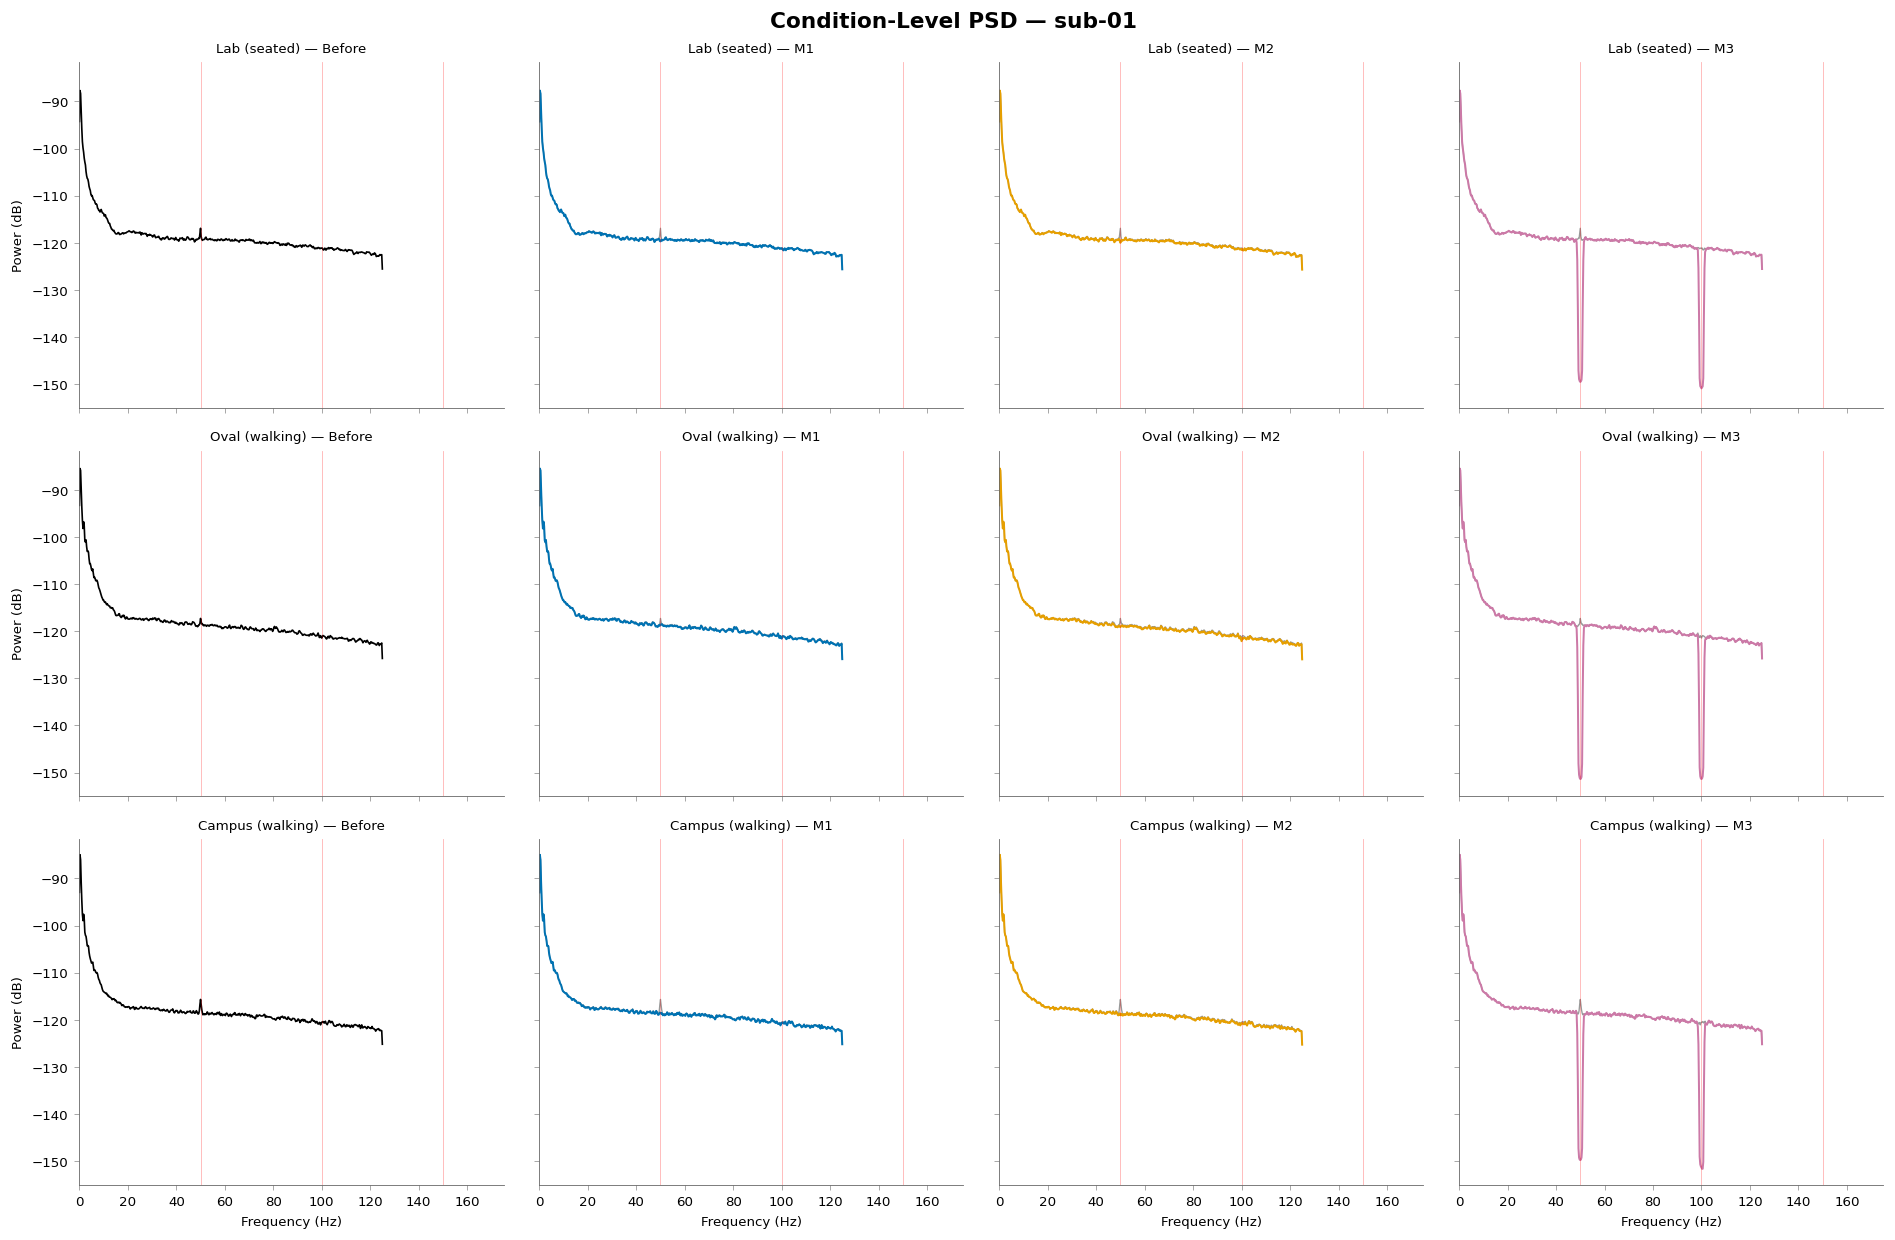

In [19]:
# ── Condition-level PSD comparison (first subject) ───────────────────────────
sub_psd = ALL_SUBJECTS[0]
raw_base_psd = load_and_preprocess(sub_psd, DATA_ROOT)
cond_blocks_psd = parse_condition_blocks(sub_psd)

# Load cleaned raws
cleaned_raws_psd = {}
for mtag in METHOD_ORDER[1:]:
    raw_path = DERIV_ROOT / sub_psd / "line_noise" / mtag / "cleaned_raw.fif"
    if raw_path.exists():
        cleaned_raws_psd[mtag] = mne.io.read_raw_fif(str(raw_path), preload=True, verbose=False)

n_methods_active = len(METHOD_ORDER[1:])
fig, axes = plt.subplots(len(CONDITIONS), n_methods_active + 1,
                         figsize=(4 * (n_methods_active + 1), 3.5 * len(CONDITIONS)),
                         sharex=True, sharey=True)
fig.suptitle(f"Condition-Level PSD — {sub_psd}", fontsize=FONTS["suptitle"], fontweight="bold")

fmax_zoom = min(LINE_FREQ * (LINE_HARMONICS + 0.5), PSD_FMAX)  # clamp to Nyquist

for row_idx, cond in enumerate(CONDITIONS):
    if cond not in cond_blocks_psd or not cond_blocks_psd[cond]:
        continue

    # Get condition segments from baseline
    pieces = []
    for tmin, tmax in cond_blocks_psd[cond]:
        seg = crop_to_condition(raw_base_psd, tmin, tmax)
        if seg is not None:
            pieces.append(seg)
    if not pieces:
        continue
    raw_cond_base = mne.concatenate_raws(pieces) if len(pieces) > 1 else pieces[0]
    freqs_cb, gm_cb = geometric_mean_psd(raw_cond_base)

    # Plot baseline
    ax = axes[row_idx, 0]
    ax.plot(freqs_cb, 10 * np.log10(gm_cb + 1e-30), color=COLORS["before"], linewidth=1, label="Before")
    for h in range(1, LINE_HARMONICS + 1):
        ax.axvline(LINE_FREQ * h, color=COLORS["accent"], alpha=0.3, linewidth=0.5)
    ax.set_title(f"{CONDITION_LABELS[cond]} — Before", fontsize=FONTS["title"])
    ax.set_xlim(0, fmax_zoom)
    if row_idx == len(CONDITIONS) - 1:
        ax.set_xlabel("Frequency (Hz)", fontsize=FONTS["label"])
    ax.set_ylabel("Power (dB)", fontsize=FONTS["label"])
    style_axes(ax)

    # Plot each method
    for m_idx, mtag in enumerate(METHOD_ORDER[1:]):
        ax = axes[row_idx, m_idx + 1]
        ax.plot(freqs_cb, 10 * np.log10(gm_cb + 1e-30), color=COLORS["before"],
                linewidth=0.8, alpha=0.4, label="Before")

        if mtag in cleaned_raws_psd:
            # Get condition segments from cleaned
            pieces_c = []
            for tmin, tmax in cond_blocks_psd[cond]:
                seg = crop_to_condition(cleaned_raws_psd[mtag], tmin, tmax)
                if seg is not None:
                    pieces_c.append(seg)
            if pieces_c:
                raw_cond_clean = mne.concatenate_raws(pieces_c) if len(pieces_c) > 1 else pieces_c[0]
                freqs_cc, gm_cc = geometric_mean_psd(raw_cond_clean)
                ax.plot(freqs_cc, 10 * np.log10(gm_cc + 1e-30),
                        color=METHOD_COLORS[mtag], linewidth=1.2, label=METHOD_LABELS[mtag])
                del raw_cond_clean

        for h in range(1, LINE_HARMONICS + 1):
            ax.axvline(LINE_FREQ * h, color=COLORS["accent"], alpha=0.3, linewidth=0.5)
        ax.set_title(f"{CONDITION_LABELS[cond]} — {mtag}", fontsize=FONTS["title"])
        ax.set_xlim(0, fmax_zoom)
        if row_idx == len(CONDITIONS) - 1:
            ax.set_xlabel("Frequency (Hz)", fontsize=FONTS["label"])
        style_axes(ax)

    del raw_cond_base

del raw_base_psd
for r in cleaned_raws_psd.values():
    del r

fig.tight_layout()
fig.savefig(GROUP_FIG_DIR / "condition_psd_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 13 — Findings & Interpretation

### Method descriptions

| Method | What it does |
|--------|-------------|
| **M0** | Baseline — no line-noise removal (reference) |
| **M1** | Standard ZapLine with automatic component selection (`n_remove="auto"`) |
| **M2** | Adaptive ZapLine+: segment-wise peak detection, adaptive n_remove per segment |
| **M3** | MNE notch filter: FIR notch at 50 Hz + harmonics (notch_widths=2 Hz) |

### Key insights

> **Adaptive ZapLine+ (M2)** handles non-stationarity in the line noise
> (frequency drift, intermittent artifacts) by processing segments
> independently.  This is especially visible in the **Campus** condition
> where walking-related movement causes fluctuating electrode impedance
> and therefore non-stationary line noise.

> **Notch filtering (M3)** applies a fixed-width FIR notch regardless
> of the instantaneous noise amplitude.  It tends to remove the same
> amount at every time point, which can over-clean quiet segments and
> under-clean noisy segments.

> The **condition-level analysis** reveals the impact of non-stationarity:
> - **Lab** (seated): relatively stationary line noise — all methods should
>   perform comparably.
> - **Oval** (walking, open field): moderate non-stationarity from movement.
> - **Campus** (walking, campus path): high non-stationarity from
>   diverse movement and environmental EMI changes.

### Acceptance criteria

| Method | R(f₀) ≈ 1? | Attn > 10 dB? | Distortion < 1 dB? | Verdict |
|--------|-------------|---------------|---------------------|---------|
| M1     | Evaluate    | Evaluate      | Evaluate            | Check   |
| M2     | Evaluate    | Evaluate      | Evaluate            | Check   |
| M3     | Evaluate    | Evaluate      | Evaluate            | Check   |

*Fill in after running with SMOKE=False on all subjects.*

### Recommendations

1. For **routine preprocessing**: use M2 (ZapLine+, adaptive) — zero tuning,
   handles non-stationarity automatically.
2. For **fixed-filter baseline**: M3 (notch filter) is useful as a
   time-domain comparison that makes no assumptions about spatial structure.
3. Always run the QA metrics above to verify cleaning quality per subject,
   and pay special attention to condition-level differences.

## 14 — Reproducibility

In [20]:
import sys, scipy
print(f"Python: {sys.version}")
print(f"MNE: {mne.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Random state: {RANDOM_STATE}")
print(f"Subjects: {ALL_SUBJECTS}")
print(f"Conditions: {CONDITIONS}")
print(f"Methods: {METHOD_ORDER}")
print(f"SMOKE mode: {SMOKE}")

Python: 3.12.9 (tags/v3.12.9:fdb8142, Feb  4 2025, 15:27:58) [MSC v.1942 64 bit (AMD64)]
MNE: 1.11.0
NumPy: 2.4.2
Pandas: 3.0.1
SciPy: 1.17.1
Matplotlib: 3.10.8
Random state: 42
Subjects: ['sub-01', 'sub-02']
Conditions: ['lab', 'oval', 'campus']
Methods: ['M0', 'M1', 'M2', 'M3']
SMOKE mode: False
